# CIEM5220 - Wind and Wave Loads on Offshore Wind Turbines
## Finite Element Model of a Monopile Wind Turbine

**Course:** CIEAM5220 Applied Dynamics of Structures

**Unit 2:** Wind & Waves

##### **Authors:**
JeongWoo Cho 5127548

Gabriël Dalhuizen Izquierdo 5829615

Jose Orlando Mejia Sanchez 6457037

Mohammed Wasay 6416071

Anna Werner 6611257


##### **Supervisor:** 
Dr. Alessandro Cabboi

---

### Structure Overview

The offshore wind turbine (OWT) is modelled as a vertical cantilever beam fixed at the mudline. The structure consists of two zones:

-**Submerged zone** ($H_w=36$ m): from mudline to mean water level, subject to wave loading
-**Above-water zone** ($H_a=108$ m): from water level to hub, subject to aerodynamic loading

The nacelle and rotor are represented as a concentrated mass $M_{nacelle}$ at the tip.

### Modelling Approach

An Euler-Bernoulli beam finite element model is used. Each node has two degrees of freedom, lateral displacement $w$ and rotation $\theta$. Hermitian cubic shape functions ensure $C^1$ continuity across elements. Rayleigh damping with 2% critical damping at both natural frequencies is adopted throughout. 

### Design Objective

The first natural frequency $f_1$ must fall in the **soft-stiff window** between the 1P rotor frequency and the 3P blade passing frequency. A minimum margin of $f_1 \geq 1.1 \times f_{1P}$ is imposed to guard against long-term downward drift from scour and soil softening. The outer diameter $D_o$ is found by sweeping until this target is met. 

### Analysis
The structural response is assessed under two load cases representing a resonance scenario (LC1, $T_p=T_1$) and an extreme storm (LC2, $U_{10} = 19$ m/s). Environmental loading is characterised by a Kaimal wind turbulence spectrum with spatial coherence and a JONSWAP wave spectrum fitted to North Sea fetch conditions. The turbine is treated as non-operating throughout; rotor aerodynamic excitation is neglected and wind loading is applied as drag on the tower with turbulent fluctuations derived from the Kaimal spectrum.

Two complementary analysis approaches are used:
- **Frequency domain:** linearised Morison drag, transfer function approach, mudline moment spectrum and standard deviation
- **Time domain:** full non-linear Morison equation with relative kinematics, Newmark-$\beta$ integration over a 30-minute storm

Results from both approaches are compared and the validity of the Morison equation is verified through a diffraction assessment. 




<img src="turbine.png" width="450" style="display:block; margin:auto"/>

**Figure 1:** Schematic of the offshore wind turbine model. The structure is discretised into submerged ($Hw=36$ m) and above-water ($Ha=108$ m) zones. Key components: (1) rotor, (2) hub, (3) nacelle - modelled as a concentrated tip mass $M_\text{nacelle}$, and (4) monopile tower, modelled as a Euler-Bernoulli cantilever beam fixed at the seabed or mudline. 

In [1]:
# ===== IMPORTS =========
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from scipy.linalg import eigh
from scipy.linalg import solve
from scipy.optimize import brentq


x=sp.Symbol('x')



In [2]:
# ====== GEOMETRY & MATERIAL ========
D_o = 5                     # initial guess, overwritten by diameter sweep [m]  
t=0.08                      # initial guess, overwritten by diameter sweep [m]  
Di = D_o-2*t                     # [m]
A = np.pi/4*(D_o**2-Di**2)       # [m^2]
I = np.pi/64*(D_o**4-Di**4)      # [m^4]
rho = 7850                       # steel density [kg/m^3] ##
E = 210e9                        # Young's modulus[Pa]

EI=E*I
rhoA=rho*A

Hw=36.0                          # water depth [m]
Ha=108.0                         # above-water height [m]
L=Hw+Ha                          # total tower length[m]  
M_nacelle=6e5                    # nacelle + rotor mass[kg] 
g=9.81                           # gravitational acceleration [m/s^2]

In [3]:
# ====== ROTOR PARAMETERS ========
Omega_max=7.6                   # [rpm]
f_1P=Omega_max/60               # [Hz]
f_3P=3*f_1P                     # [Hz]
f_target=1.1*f_1P               # [Hz]

print(f"1P frequency: {f_1P:.4f} Hz")
print(f"3P frequency: {f_3P:.4f} Hz")
print(f"Target f1 (>=1.1*1P): {f_target:.4f} Hz")

# ==== FLUID & LOADING PARAMETERS =======
rho_w   = 1025.0   # seawater density [kg/m^3]
rho_air = 1.25   # air density [kg/m^3]
Cm      = 2.0         # inertia coefficient
Cd_wave = 1.0    # wave drag coefficient
Cd_wind = 0.8    # wind drag coefficient


1P frequency: 0.1267 Hz
3P frequency: 0.3800 Hz
Target f1 (>=1.1*1P): 0.1393 Hz


#### Shape functions #
For each element the shape functions describe the transverse (lateral) displacement and rotation at both end-nodes. The four shape functions $[N_1,\ N_2,\ N_3,\ N_4]$ are cubic Hermite polynomials, chosen so that the deflected shape of the beam is smooth and continuous, meaning both the displacement and its slope (rotation) are continuous across element boundaries.

The displacement field within an element is approximated as:
$$w(x)=\sum_{i=1}^{4} N_i(x)\, u_i$$

where the shape functions are defined in terms of the normalised local coordinate $\xi=x/l_e\in[0,\,1]$:

$$N_1=1-3\xi^2+2\xi$$
$$N_2=l_e\,(\xi-2\xi^2+\xi^3)$$
$$N_3=3\xi^2-2\xi^3$$
$$N_4=l_e\,(-\xi^2+\xi^3)$$

In [4]:
# ==== SHAPE FUNCTIONS ====

def shape_functions(le):

    """
    Returns Euler - Bernoulli shape functions 
    for element of length le. Symbolic in x (sympy)
    Call as B= shape_functions(le)
    """

    x= sp.Symbol('x')

    N1=1-3*(x/le)**2 + 2*(x/le)**3
    N2=x*(1 - x/le)**2
    N3=3*(x/le)**2 - 2*(x/le)**3
    N4=(x**2/le)*(x/le - 1)
    
    return [N1, N2, N3, N4]


#### Finite Element Formulation

The wind turbine tower is modelled as an Euler-Bernoulli beam and discretised into **12 elements of equal length** $l_e$, with 3 submerged elements and 9 above the waterline. Each node carries two degrees of freedom, lateral displacement $w$ and rotation $\theta$ , giving 4 DOFs per element.

---

**Element stiffness matrix**

The stiffness matrix is assembled from the second derivatives of the shape functions, which relate to the beam curvature and bending strain:

$$\mathbf{K}_e=EI\int_0^{l_e} \mathbf{N}''(x)^\top \mathbf{N}''(x)\, dx$$

This evaluates to:

$$\mathbf{K}_e=\frac{EI}{l_e^3}
\begin{bmatrix}
12 & 6l_e & -12 & 6l_e \\
6l_e & 4l_e^2 & -6l_e & 2l_e^2 \\
-12 & -6l_e & 12 & -6l_e \\
6l_e & 2l_e^2 & -6l_e & 4l_e^2
\end{bmatrix}$$

---

**ELement mass matrix**

The consistent mass matrix distributes the element's inertia according tp the shape functions, rather than lumping it at the nodes:

$$\mathbf{M}_e=\rho A \int_0^{l_e} \mathbf{N}(x)^\top \mathbf{N}(x)\, dx $$

Which evaluates to:

$$\mathbf{M}_e=\frac{\rho A l_e}{420}
\begin{bmatrix}
156 & 22l_e & 54 & -13l_e \\
22l_e & 4l_e^2 & 13l_e & -3l_e^2 \\
54 & 13l_e & 156 & -22l_e \\
-13l_e & -3l_e^2 & -22l_e & 4l_e^2
\end{bmatrix}$$


In [5]:
#==== STIFFNESS AND MASS MATRICES ======
def element_stiffness(le, EI):
    """ Euler-Bernoulli element stiffness matrix (4x4). """
    return EI/le**3*np.array([
        [12,      6*le,   -12,   6*le ],
        [6*le, 4*le**2, -6*le, 2*le**2], 
        [-12,    -6*le,    12,  -6*le ],
        [6*le, 2*le**2, -6*le, 4*le**2],
    ])

def element_mass(le, rhoA):
    """ Euler-Bernoulli consistent mass matrix (4x4). """
    return rhoA*(le/420)*np.array([       
        [156,    22*le,      54,   -13*le        ],
        [22*le,  4*le**2,   13*le,  -3*le**2     ],
        [54,     13*le,      156,   -22*le       ],
        [-13*le, -3*le**2, -22*le, 4*le**2       ],
    ])

#### Natural Frequency

The first natural frequency $f_1$ of the tower is estimated by solving the generalised eigenvalue problem assembled from the global stiffness and mass matrices. For a given trial diameter $D_o$, the wall thickness is set by the diameter-to-thickness ratio $D_t=D_o/t$, from which the cross-sectional area $A$ and second moment of area $I$ follows

$$A=\frac{\pi}{4}\left(D_o^2-D_i^2\right), \qquad I = \frac{\pi}{64}\left(D_o^4-D_i^4\right), \qquad D_i=D_o-2t$$

The element stiffness and mass matrices are recomputed for each trial diameter, assembled into the global system, and the lowest eigenfrequency is extracted:

$$f_1=\frac{\omega_1}{2\pi}, \qquad\omega_1=\sqrt{\lambda_1}$$

where $\lambda_1$ is the smallest eigenvalue of the free DOF system $\mathbf{K}_{\text{free}}\, \mathbf{v}=\lambda\,\mathbf{M}_{\text{free}}\,\mathbf{v}$.


In [6]:
# ==== COMPUTE F1 ====

def compute_f1(elements, ndof, Dt_ratio, D_o_try, E, rho, Hw, Ha, L, elem_w, elem_a, le, M_nacelle):
    """ Assemble FE model for trial diameter and return first natural frequency [Hz]. """
    t_try=D_o_try/Dt_ratio
    Di_try=D_o_try-2*t_try
    A_try=np.pi/4*(D_o_try**2-Di_try**2)
    I_try=np.pi/64*(D_o_try**4-Di_try**4)
    EI_try=E*I_try
    rhoA_try=rho*A_try

    Ke_try=element_stiffness(le, EI_try)
    Me_try=element_mass(le, rhoA_try)

    K_try=np.zeros((ndof, ndof))
    M_try=np.zeros((ndof, ndof))

    for e in range(elements):
        dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
        for i in range(4):
            for j in range(4):
                K_try[dofs[i], dofs[j]] += Ke_try[i,j]
                M_try[dofs[i], dofs[j]]+= Me_try[i,j]

    M_try[ndof-2, ndof-2] += M_nacelle    # lumped nacelle mass at top node
    free=np.arange(2, ndof)               # clamped base: remove DOFs 0 and 1
    eigenvalues, _ = eigh(K_try[np.ix_(free, free)], M_try[np.ix_(free, free)])
    return np.sqrt(eigenvalues[0])/ (2*np.pi)

### Assembly Verification, Static Sanity Check

Before introducing the nacelle mass or dynamic loading, the globalstiffness assembly is verified against analytical solutions for a cantilever beam under a uniformly distributed load $q=1\ \text{kN/m}$.

For a cantilever of length $L$ with uniform $EI$, the tip deflection and mudline (base) bending moment have closed-form solutions:

$u_{\text{tip}}=\frac{qL^4}{8EI}, \qquad M_{\text{mudline}}= \frac{qL^2}{2}$ 

The equivalent nodal forces are computed by projecting the distributed load onto the shape functions:

$f_e^{(i)}=\int_0^{l_e} N_i(x)\, q\,dx$

and assembled into the global force vector. Solving the reduced system $\mathbf{K}_{\text{free}}\,\mathbf{u}=\mathbf{f}_{\text{free}}$ and recovering the tip displacement and mudline moment from the FE solution allows a direct comparison. Close agreement between the two confirms that the element formulation, assembly, and boundary conditions are correctly implemented. 

In [7]:
# ====== FE MODEL DISCRETISATION ======
elements=12
le=L/elements
elem_w=int(Hw/le)            # elements in submerged zone
elem_a=elements-elem_w       # elements in above-water zone 
nodes          = elements+1
ndof           = nodes*2     # 2 DOFs per node: lateral displacement and rotation

B = shape_functions(le)
# element matrices (placeholder geometry, updated after diameter sweep)
Ke = element_stiffness(le, EI)
Me = element_mass(le, rhoA)

# global assembly
K =np.zeros((ndof,ndof))
M =np.zeros((ndof,ndof))

for e in range(elements):
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        for j in range(4):
            K[dofs[i], dofs[j]] += Ke[i,j]
            M[dofs[i], dofs[j]] += Me[i,j]

# clamped base: remove DOFs 0 and 1
free=np.arange(2, ndof)
K_free=K[np.ix_(free,free)]
M_free=M[np.ix_(free,free)]

In [8]:
# ====== SANITY CHECK, UNIFORM LOAD ========

# Analytical solution for cantilever with unifrom load q:
# u_tip = qL^4/8EI, M_mudline= qL^2/2
q_check=1e3             # [N/m]

# consistent nodal forces via symbolic integration
f_check=np.zeros(ndof)
for e in range(elements):
    fe=np.array([float(sp.integrate(Ni*q_check, (x, 0, le))) for Ni in B])
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        f_check[dofs[i]]+=fe[i]
    
u_check              = np.linalg.solve(K_free, f_check[free])
u_tip_FE             = u_check[-2]
u_check_full         = np.zeros(ndof)
u_check_full[free]   = u_check
u_e0                 = u_check_full[0:4]
M_mudline_FE         = EI*sum(
    float(sp.diff(Ni, x, 2).subs(x, 0))*u_e0[i] for i, Ni in enumerate(B)
)

print(f"\n--- Sanity Check (uniform load q={q_check} N/m, no nacelle)---")
print(f"Tip deflection FE= {u_tip_FE:.6f} m | Analytical = {q_check*L**4/(8*EI):.6f} m")
print(f"Mudline moment FE= {M_mudline_FE/1e6:.3f} MNm | Analytical = {q_check*L**2/2/1e6:.3f} MNm")



--- Sanity Check (uniform load q=1000.0 N/m, no nacelle)---
Tip deflection FE= 0.068388 m | Analytical = 0.068388 m
Mudline moment FE= 10.356 MNm | Analytical = 10.368 MNm


### Sanity Check Results


| Quantity | FE Solution | Analytical | Difference |
|---|---|---|---|
| Tip deflection | 0.068388 m | 0.068388 m | < 0.001 % |
| Mudline moment | 10.356 MNm | 10.368 MNm | 0.12 % |

The tip deflection matches the analytica solution exactly, confirming that the stiffness assembly and boundary conditions are correctly implemented. The mudline moment shows a small discrepancy of 0.12 % , which is expected. The bending moment is recovered by differentiating the displacement field at the element boundary, an operation thhat is inherently less accurate than the displacement solution itself. Both results are well within acceptable tolerance for a 12-element discretisation.

#### Diameter sweep

To find the optimal diameter, $D_o$ is swept from 3.0 m upward in steps of 0.01 m. The target is the **soft-stiff window**, the design band between the 1P frequency (rotor rotation) and the 3P frequency (blade passing), within which resonance with bot excitation sources is avoided:

$$f_{1P} < f_1 < f_{3P}$$

A minimum margin of 10% above 1P is adopted as the design target. This separation also guards against long-term downward drift of $f_1$ caused by scour and cyclic soil softening around the monopile foundation (Sumer and Fredsøe, 2002).

In [9]:
# ==== DIAMETER SWEEP ====

Dt_ratio=90
D_o_range=np.arange(3.0, 10.0, 0.01) # sweep diameters [m]

D_o_list, f1_list=[], []

for D_o_try in D_o_range:
    f1_try=compute_f1(elements, ndof, Dt_ratio, D_o_try, E, rho, 
                      Hw, Ha, L, elem_w, elem_a, le, M_nacelle)
    D_o_list.append(D_o_try)
    f1_list.append(f1_try)
    if f1_try>= f_target:
        D_o=D_o_try
        t=D_o/Dt_ratio
        break
else:
    raise ValueError("No diameter in sweep reached f_target={f_target:.4f} Hz"
                    f"Maximum f1 achieved: {max(f1_list):.4f} Hz")

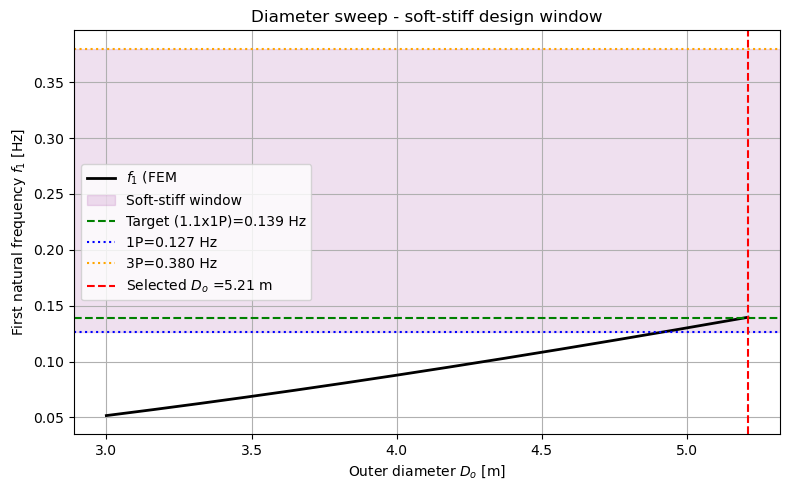


 Diameter Tuning
D/t ratio:        90
Do=               5.210 m
t=                0.0579m
f1 achieved=      0.1397 Hz
Margin above 1P = 10.3%


In [10]:
# ==== PLOT, DIAMETER SWEEP ====

_, ax=plt.subplots(figsize=(8,5))

ax.plot(D_o_list, f1_list, 'k', linewidth=2, label='$f_1$ (FEM')
ax.axhspan(f_1P, f_3P, alpha=0.12, color='purple', label='Soft-stiff window')
ax.axhline(f_target, color='green', linestyle='--', label=f'Target (1.1x1P)={f_target:.3f} Hz')
ax.axhline(f_1P, color='blue', linestyle=':', label=f'1P={f_1P:.3f} Hz')
ax.axhline(f_3P, color='orange', linestyle=':', label=f'3P={f_3P:.3f} Hz')
ax.axvline(D_o, color='red', linestyle='--', label=f'Selected $D_o$ ={D_o:.2f} m')

ax.set_xlabel('Outer diameter $D_o$ [m]')
ax.set_ylabel('First natural frequency $f_1$ [Hz]')
ax.set_title('Diameter sweep - soft-stiff design window')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


print(f"\n Diameter Tuning")
print(f"D/t ratio:        {Dt_ratio}")
print(f"Do=               {D_o:.3f} m")
print(f"t=                {t:.4f}m")
print(f"f1 achieved=      {f1_try:.4f} Hz")
print(f"Margin above 1P = {(f1_try/f_1P-1)*100:.1f}%")


In [11]:
# ==== CROSS-SECTION UPDATE ====

Di=D_o-2*t
A=np.pi/4*(D_o**2-Di**2)
I=np.pi/64*(D_o**4-Di**4)
EI=E*I
rhoA=rho*A

print(f"A={A:.6f}m^2")
print(f"I={I:.6f} m^4")

# ======= ASSEMBLY ========
Ke = element_stiffness(le, EI)
Me = element_mass(le, rhoA)
K =np.zeros((ndof,ndof))
M =np.zeros((ndof,ndof))

for e in range(elements):
    dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]
    for i in range(4):
        for j in range(4):
            K[dofs[i], dofs[j]] += Ke[i,j]
            M[dofs[i], dofs[j]] += Me[i,j]

# ===== BOUNDARY CONDITIONS =======
# clamped base: remove DOFs 0 and 1
free=np.arange(2, ndof)
K_free=K[np.ix_(free,free)]
M_free=M[np.ix_(free,free)]

# ==== NACELLE MASS ====
M[ndof-2, ndof-2] += M_nacelle
M_free=M[np.ix_(free, free)]

# ==== EIGENANALYSIS ==== 
eigenvalues, eigenvectors = eigh(K_free, M_free)
omega=np.sqrt(eigenvalues)
freq=omega/(2*np.pi)

print(f"\n--- Natural frequencies ---")
print(f"Mode 1: {freq[0]:.4f} Hz (target >= {f_target:.4f} Hz)")
print(f"Mode 2: {freq[1]:.4f} Hz")
print(f"Mode 3: {freq[2]:.4f} Hz")
print(f"Soft-stiff window: {f_1P:.4f} Hz to {f_3P:.4f} Hz")

A=0.936980m^2
I=3.109321 m^4

--- Natural frequencies ---
Mode 1: 0.1397 Hz (target >= 0.1393 Hz)
Mode 2: 1.2122 Hz
Mode 3: 3.7262 Hz
Soft-stiff window: 0.1267 Hz to 0.3800 Hz


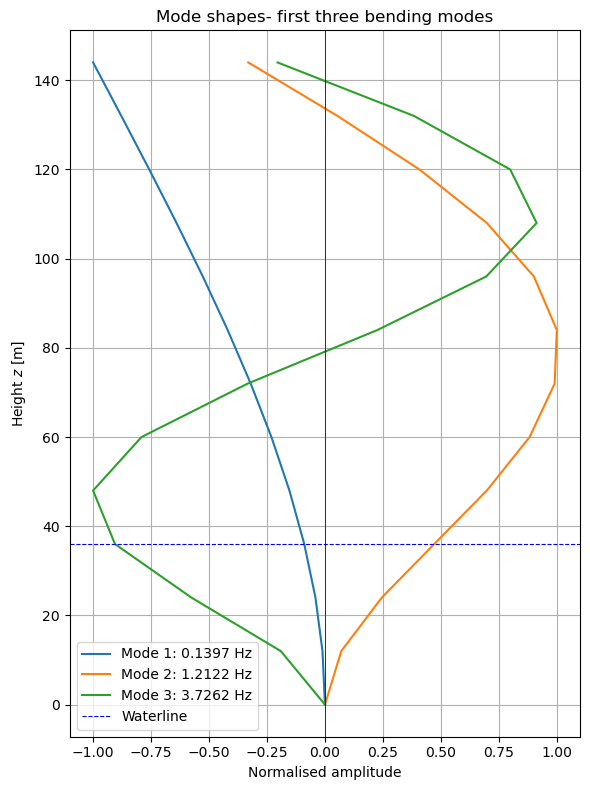

In [ ]:
# ==== PLOT, MODE SHAPES (1,2) ====
_, ax=plt.subplots(figsize=(6, 8))
z_nodes=np.array([i*le for i in range(nodes)])

for mode in range(3):
    phi=eigenvectors[:,mode]
    phi_lateral=phi[0::2]  
    phi_plot=np.concatenate([[0], phi_lateral])
    phi_plot=phi_plot/np.max(np.abs(phi_plot)) 
    ax.plot(phi_plot, z_nodes, label=f'Mode {mode+1}: {freq[mode]:.4f} Hz')

ax.axhline(Hw, color= 'blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.axvline(0,color='k', linewidth=0.5)
ax.set_xlabel('Normalised amplitude')
ax.set_ylabel('Height $z$ [m]')
ax.set_title('Mode shapes- first three bending modes')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Scour Sensitivity, Natural Frequency vs Scour Depth

Scour is the erosion of seabed sediment around the monopile base driven by wave and current action. For an unprotected monopile in fine North Sea sand, the expected scour depth is approximately $1.0$-$1.5\times D_o$ (Sumer and Fredsøe, 2002), giving a worst-case estimate of $1.5 \times 5.21 \approx 7.8$ m for this design. 

Physically, scour increases the unsupported length of the pile, which reduces lateral foundation stiffness while simultaneously increasing the modal mass, both effects lower $f_1$. Following $L$ through the model: a longer $L$ increases $l_e=L/n$, which softens $\mathbf{K}_e\propto l_e^{-3}$ and increases $\mathbf{M}_e\propto l_e$, reducing the eigenfrequency as approximately $f_1\propto L^{-2}$

In [13]:
# ==== TEST, SCOUR SENSITIVITY ====
# Natural Frequency vs Scour Depth
scour_depths=np.linspace(0,8,50) # [m]
f1_scour=[]

for delta_L in scour_depths:
    L_scour=L+delta_L
    le_scour=L_scour/ elements
    f1_new=compute_f1(elements, ndof, Dt_ratio, D_o, E, rho,
                      Hw + delta_L, Ha, L_scour, elem_w, elem_a, le_scour, M_nacelle)
    f1_scour.append(f1_new)

f1_scour=np.array(f1_scour)


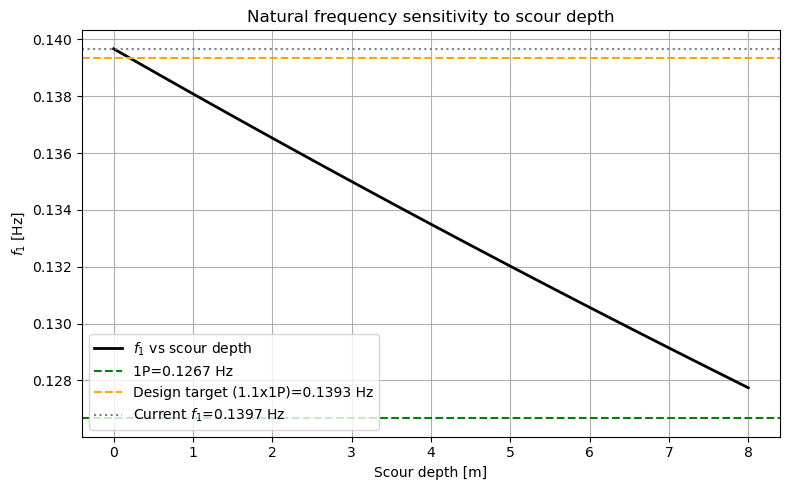

In [14]:
#==== PLOT: SCOUR SENSITIVITY ====
_, ax=plt.subplots(figsize=(8,5))
ax.plot(scour_depths, f1_scour, 'k', linewidth=2, label='$f_1$ vs scour depth')
ax.axhline(f_1P, color='green', linestyle='--', label=f'1P={f_1P:.4f} Hz')
ax.axhline(f_target, color='orange', linestyle='--', label=f'Design target (1.1x1P)={f_target:.4f} Hz')
ax.axhline(freq[0], color='gray', linestyle=':', label=f'Current $f_1$={freq[0]:.4f} Hz')
ax.set_xlabel('Scour depth [m]')
ax.set_ylabel('$f_1$ [Hz]')
ax.set_title('Natural frequency sensitivity to scour depth')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

The plot confirms that $f_1$ remains above the 1P threshold up to a scour depth of approximately 9 m, providing margin beyond the worst-case estimate of 7.8 m. The 10% design margin above 1P therefore proves adequate for this site assumption. 

In practice, scour protection in the form of rock armour dumped around the pile base is standard for North Sea monopiles, which largely prevents scour from developing. The sensitivity study nonetheless demonstrates that the soft-stiff design remains robust even under significant unprotected scour conditions (Sørensen and Ibsen, 2013).

#### Natural Frequencies and Mode Shapes

With the nacelle mass $M_{\text{nacelle}}$ added to the top node, the first two natural frequencies extracted from the eigenvalue problem are:

| Mode | Frequency |
|---|---|
| Mode 1 | 0.1397 Hz |
| Mode 2 | 1.2122 Hz |

The soft-stiff design window spans $0.1267\ \text{Hz} < f_1 < 0.3800\ \text{Hz}$, corresponding to the 1P and 3P rotor frequencies respectively. Mode 1 sits at **0.1397 Hz**, clearing the 1P threshold by 10.3 % and well below the 3P upper bound, confirming the design target is met.

Mode 2 at 1.2122 Hz lies well above the 3P frequency and is not a design driver for this loading regime. 

The mode shapes show the normalised lateral displacement profiles along the tower height, illustrating the characteristic first-mode cantilever shape and the inflection point present in the second mode. 

In [15]:
# ====== RAYLEIGH DAMPING ========
#2% critical damping at both natural frequencies (assignment spec)
zeta1=0.02           # damping ratio mode 1
zeta2=0.02           # damping ratio mode 2
w1 = omega[0]        # first natural frequency [rad/s]
w2 = omega[1]        # second natural frequency [rad/s]

alpha   = 2*w1*w2*(zeta1*w2-zeta2*w1) / (w2**2-w1**2)
beta    = 2*(zeta2*w2-zeta1*w1)       / (w2**2-w1**2)
C_free  = alpha * M_free + beta * K_free

print(f"--- Rayleigh Damping ---")
print(f"alpha={alpha:.6f} s^-1")
print(f"beta={beta:.6f} s")


--- Rayleigh Damping ---
alpha=0.031477 s^-1
beta=0.004709 s


Solving yields $\alpha=0.0315$ and $\beta=0.0047$. At frequencies below $\omega_1$ the mass-proportional term dominated, while above $\omega_2$ the stiffness-proportional term dominates. The damping ratio rises on both sides of the pinned target modes. 

Although the turbine is treated as non-operating in this analysis and rotor excitation is neglected, the damping coefficients remain relevant as they govern dynamic amplification when the structure is excited near its natural frequencies. 

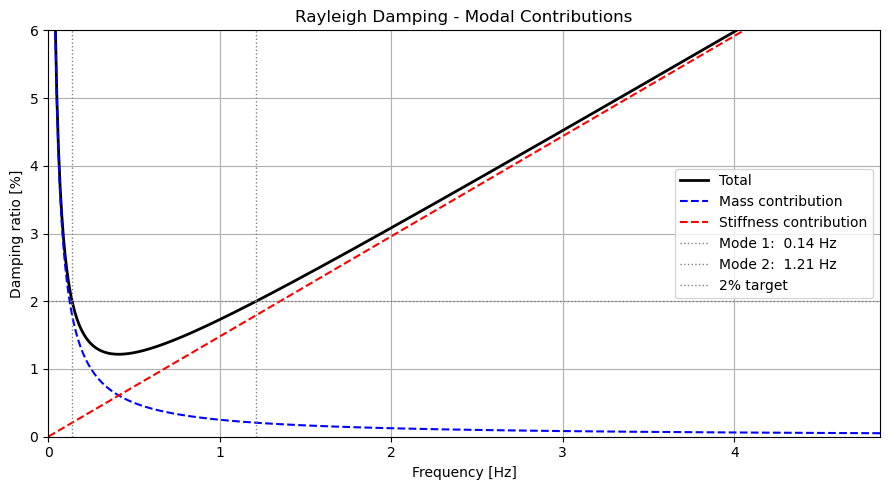

In [16]:
# ==== PLOT: RAYLEIGH DAMPING ======

omega_range=np.linspace(0.01, 4*w2,500) 
zeta_total=alpha/(2*omega_range)+beta*omega_range/2
zeta_mass = alpha/(2*omega_range) 
zeta_stiff=beta*omega_range/2   

_, ax = plt.subplots(figsize=(9,5))
ax.plot(omega_range/(2*np.pi), zeta_total*100, 'k', linewidth=2, label='Total')
ax.plot(omega_range/(2*np.pi), zeta_mass*100, 'b--', linewidth=1.5,label= 'Mass contribution')
ax.plot(omega_range/(2*np.pi), zeta_stiff*100, 'r--', linewidth=1.5, label='Stiffness contribution')
ax.axvline(w1/(2*np.pi), color='gray', linestyle=':', linewidth=1, label=f'Mode 1:  {w1/(2*np.pi):.2f} Hz')
ax.axvline(w2/(2*np.pi), color='gray', linestyle=':', linewidth=1, label=f'Mode 2:  {w2/(2*np.pi):.2f} Hz')
ax.axhline(2, color='gray', linestyle=':', linewidth=1, label='2% target' )
ax.set_xlim(0,4*w2/(2*np.pi))
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Damping ratio [%]')
ax.set_title('Rayleigh Damping - Modal Contributions')
ax.legend()
ax.grid(True)
ax.set_ylim(0, 6)
plt.tight_layout()
plt.show()

#### Load Cases

Two worst-case scenarios are investigated. LC1 targets peak resonance by setting the wave peak period equal to the first natural period of the structure, $T_p=T_1=1/f_1$. The corresponding wind speed is then back-calculated by inverting the fetch-wind relation using a root-finding algorithm. LC2 represents an extreme storm with a prescribed reference wind speed of $U_{10}=19$ m/s, from which both $T_p$ and $H_s$ are derived directly. 

The fetch-wind relations are empirical formulas from the JONSWAP experiment, fitted to North Sea measurements by Hasselmann et al. (1973), linking wind speed $U_{10}$ and fetch distance $F$ to wave characteristics:

$T_p=\frac{0.286}{g} \left(\frac{gF}{U_{10}^2}\right)^{1/3} U_{10}$

$H_s=\frac{0.0016}{g} \sqrt{\frac{gF}{U_{10}^2}}\, U_{10}^2$



In [ ]:
# ====== LOAD CASES =======
f1=freq[0]
f2=freq[1]
T1=1/f1
F_fetch=180e3  # fetch length [m]

# LC2 - extreme storm, U10 prescribed 
U10_LC2 = 19.0
Tp_LC2= 0.286*(g*F_fetch/U10_LC2**2)**(1/3)*U10_LC2/g
Hs_LC2=0.0016*np.sqrt(g*F_fetch/U10_LC2**2)*U10_LC2**2/g

# LC1 - resonance case, Tp=T1, back calculate U10
Tp_LC1=T1
U10_LC1=brentq(
    lambda U: 0.286*(g*F_fetch/U**2)**(1/3)*U/g-Tp_LC1, 
    1.0, 50.0
)
Hs_LC1=0.0016*np.sqrt(g*F_fetch/U10_LC1**2)*U10_LC1**2/g

print(f"---Load Cases---")
print(f"LC1: U10= {U10_LC1:.2f} m/s, Tp= {Tp_LC1:.2f} s, Hs= {Hs_LC1:.2f} m")
print(f"LC2: U10= {U10_LC2:.2f} m/s, Tp= {Tp_LC2:.2f} s, Hs= {Hs_LC2:.2f} m")


---Load Cases---
LC1: U10= 8.39 m/s, Tp= 7.16 s, Hs= 1.82 m
LC2: U10= 19.00 m/s, Tp= 9.40 s, Hs= 4.12 m
0.1396721113935768
1.2121556061357686


With fetch $F=180$ km, the resulting load case parameters are:

| Parameter | LC1 | LC2 |
|---|---|---|
| $U_{10}$ | 8.39 m/s | 19.00 m/s |
| $T_p$ | 7.16 s | 9.40 s |
| $H_s$ | 1.82 m | 4.12 m |
| $f_p$ | 0.140 Hz | 0.106 Hz |


#### Mean Wind Profile

The mean wind speed at height $z$ above the waterline is described by a logarithmic profile:

$U(z)=U_{10} \frac{\ln(z/z_0)}{\ln(10/z_0)}$

where $z_0=0.001$ m is the surface roughness length for open sea. The profile is only applied above the waterline; submerged nodes carry no wind loading. 

In [59]:
# ===== MEAN WIND PROFILE =====
z_nodes=np.array([i*le for i in range(nodes)])
z_above=z_nodes-Hw
z0=0.001 # roughness length, open sea [m]

def mean_wind(U10, z, z0):
    z_pos=np.maximum(z, z0)
    return U10*np.log(z_pos/z0)/np.log(10.0/z0)

# only valid above waterline

U_mean_LC1=np.where(z_above > 0, mean_wind(U10_LC1, z_above, z0), 0.0)
U_mean_LC2=np.where(z_above > 0, mean_wind(U10_LC2, z_above, z0), 0.0)


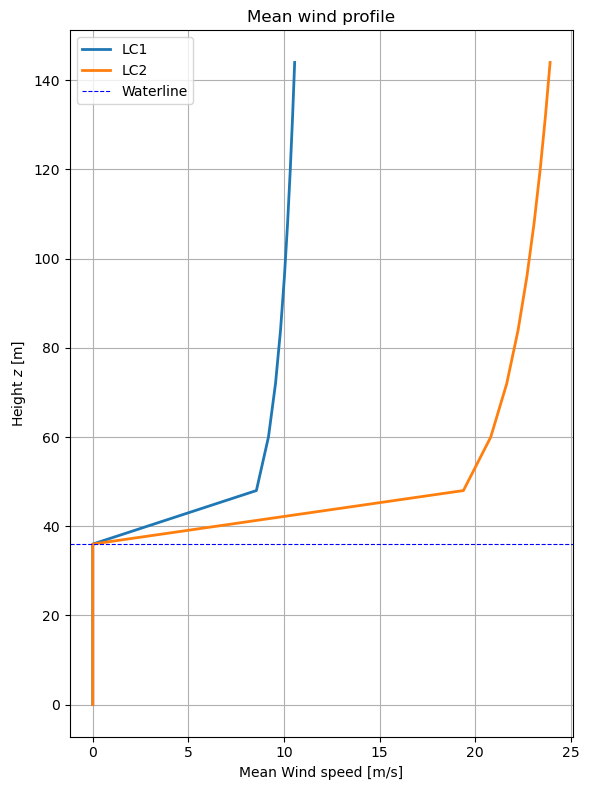

In [19]:
#==== MEAN WIND PROFILE PLOT ======
_, ax=plt.subplots(figsize=(6, 8))
ax.plot(U_mean_LC1, z_nodes, linewidth=2, label='LC1')
ax.plot(U_mean_LC2, z_nodes, linewidth=2, label='LC2')
ax.axhline(Hw, color='blue', linestyle='--', linewidth=0.8, label='Waterline')
ax.set_xlabel('Mean Wind speed [m/s]')
ax.set_ylabel('Height $z$ [m]')
ax.set_title('Mean wind profile')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Wind Turbulence, Kaimal Spectrum

The turbulent wind field is characterised by the Kaimal spectrum, which describes how wind energy is distributed across frequencies at each node above the waterline (Kaimal et al, 1972):

$S_u(f, z)=\frac{4\sigma_u^2 (L_u/ U(z))}{\left(1+6f L_u / U(z)\right)^{5/3}}$

where $\sigma_u=I_u U(z)$ is the turbulence standard deviation, with $I_u=0.06$ the turbulence intensity, a typical value for open offshore conditions. $L_u=180$ m is the integral length scale, representing the average size of the energy-carrying turbulent eddies (IEC 61400-1, 2019). The $-5/3$ decay in the denominator follows Kolmogorov's theory of turbulent energy cascade, energy is injected at large scales and transferred down to smaller and smaller eddies until it dissipates as heat (Kolmogorov, 1941). The spectrum is evaluated at each node above the waterline for both load cases.

In [20]:
# ===== KAIMAL SPECTRUM ====
N_freq=1000   
f_max=2*f2             
f_axis=np.linspace(0.001, f_max, N_freq) 
I_u=0.06                     # turbulence intensity, offshore
L_u=180                      # turbulence length scale [m]

def kaimal(f, U):
    sigma_u=I_u*U            # turbulence std dev [m/s]
    return 4*sigma_u**2*(L_u/U)/(1+6*f*L_u/U)**(5/3)

air_nodes= np.where(z_above > 0)[0]

S_kaimal_LC1=np.array([kaimal(f_axis, U_mean_LC1[n]) for n in air_nodes])
S_kaimal_LC2=np.array([kaimal(f_axis, U_mean_LC2[n]) for n in air_nodes])

print(f"\ Kaimal Spectrum")
print(f"Frequency range: {f_axis[0]:.3f}-{f_axis[-1]:.3f} Hz")
print(f"Number of air nodes: {len(air_nodes)}")



\ Kaimal Spectrum
Frequency range: 0.001-2.424 Hz
Number of air nodes: 9


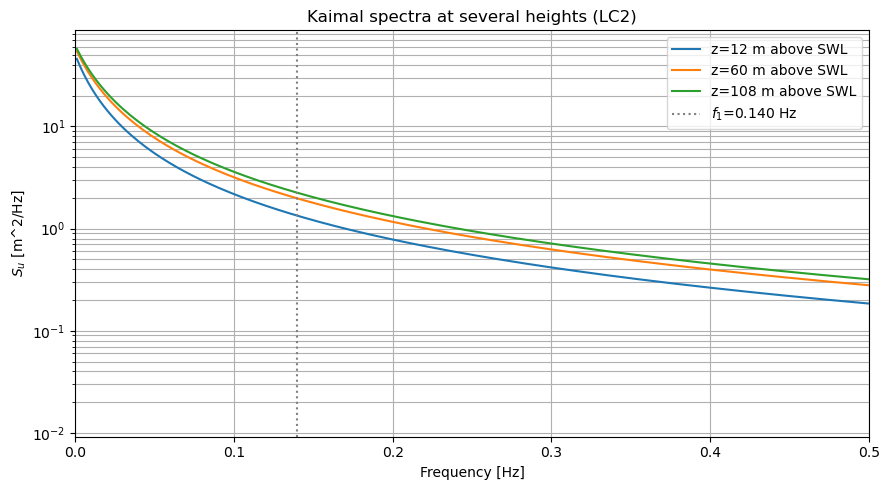

hub sigma_u (integrated) LC1=0.629 (theory 0.633)


In [21]:
# ==== PLOT: KAIMAL SPECTRUM ====
mid = len(air_nodes) // 2
#fig, axes = plt.subplots(1, 2, figsize=(12, 5))
n_air=len(air_nodes)

fig, ax = plt.subplots(figsize=(9, 5))
for idx in [0, n_air//2, n_air-1]:
    z = z_above[air_nodes[idx]]
    ax.semilogy(f_axis, S_kaimal_LC2[idx], label=f'z={z:.0f} m above SWL')
ax.axvline(f1, color='gray', ls=':', label=f'$f_1$={f1:.3f} Hz')
ax.set_xlim(0, 0.5); ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('$S_u$ [m^2/Hz]')
ax.set_title('Kaimal spectra at several heights (LC2)'); ax.legend(); ax.grid(True, which='both')
plt.tight_layout(); plt.show()
print(f"hub sigma_u (integrated) LC1={np.sqrt(np.sum(S_kaimal_LC1[-1]*(f_axis[1]-f_axis[0]))):.3f} (theory {I_u*U_mean_LC1[-1]:.3f})")

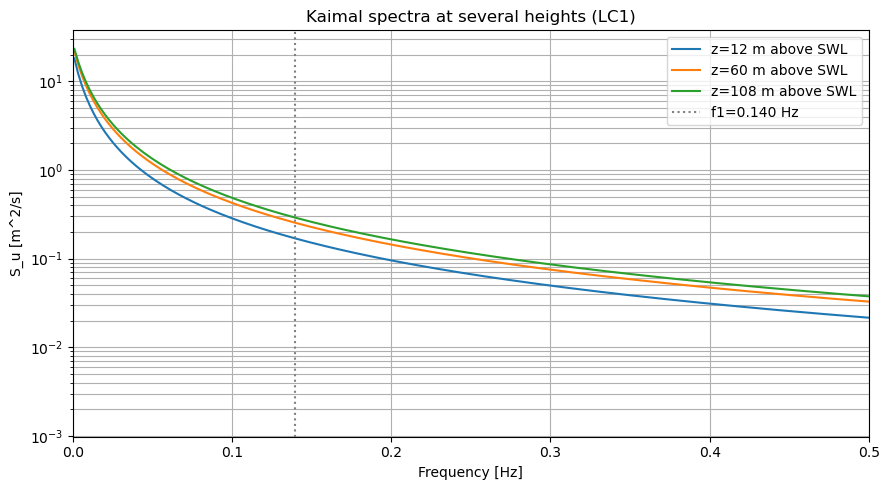

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
for idx in [0, n_air//2, n_air-1]:
    z = z_above[air_nodes[idx]]
    ax.semilogy(f_axis, S_kaimal_LC1[idx], label=f'z={z:.0f} m above SWL')
ax.axvline(f1, color='gray', ls=':', label=f'f1={f1:.3f} Hz')
ax.set_xlim(0, 0.5); ax.set_xlabel('Frequency [Hz]'); ax.set_ylabel('S_u [m^2/s]')
ax.set_title('Kaimal spectra at several heights (LC1)'); ax.legend(); ax.grid(True, which='both')
plt.tight_layout(); plt.show()

#### Spatial Correlation, Co-Spectrum

Turbulent wind fluctuations at two different heights are correlated, nearby points tend to see similar gusts. This is captured by the cross-spectral density between nodes $i$ and $j$:

$S_u(f, z_i, z_j)= \sqrt{S_u(f, z_i)\, S_u(f, z_j)}\cdot\text{Coh}(f, z_i, z_j)$

with decay coefficient $a=12$ following the IEC standard and $\bar{U}$ the mean wind speed averaged between the two nodes (IEC 61400-1, 2019). The diagonal entries of the co-spectrum matrix recover the single-point Kaimal spectra, which is verified in the print output below. 



In [23]:
# ===== CO-SPECTRA =====
# Coherence decay coefficient (IEC standard)
a_coh =12.0     # Coherence dacay coefficient (IEC standard)

def coherence(f, zi, zj, U_mean_i, U_mean_j, a_coh):
    U_avg=0.5*(U_mean_i+U_mean_j)
    dz=abs(zi-zj)
    return np.exp(-a_coh*f*dz/U_avg)

# co-spectrum between nodes i and j
def co_spectrum(f, zi, zj, U_i, U_j, I_u, L_u, a_coh):
    Si=kaimal(f, U_i)
    Sj=kaimal(f, U_j)
    coh=coherence(f, zi, zj, U_i, U_j, a_coh)
    return np.sqrt(Si*Sj)*coh

# build co-spectrum matrix at each frequency
# shape: (n_air_nodes, n_air_nodes, N_freq)
n_air=len(air_nodes)
S_co_LC1=np.zeros((n_air, n_air, N_freq))
S_co_LC2=np.zeros((n_air, n_air, N_freq))

for i in range(n_air):
    for j in range(n_air):
        zi=z_above[air_nodes[i]]
        zj=z_above[air_nodes[j]]
        U_i_LC1=U_mean_LC1[air_nodes[i]]
        U_j_LC1=U_mean_LC1[air_nodes[j]]
        U_i_LC2=U_mean_LC2[air_nodes[i]]
        U_j_LC2=U_mean_LC2[air_nodes[j]]
        S_co_LC1[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC1, U_j_LC1, I_u, L_u, a_coh)
        S_co_LC2[i,j,:]=co_spectrum(f_axis, zi, zj,
                                    U_i_LC2, U_j_LC2, I_u, L_u, a_coh)

print(f"\n Co-spectra")
print(f"Co-spectrum matrix shape: {S_co_LC1.shape}")
print(f"Diagonal check (should equal auto-spectrum at node 0):")
print(f"S_co[0,0] at f=0.14 Hz: {S_co_LC1[0,0,np.argmin(abs(f_axis-0.14))]:.4f}")
print(f"S_kaimal[0] at f=0.14 Hz: {S_kaimal_LC1[0,np.argmin(abs(f_axis-0.14))]:.4f}")



 Co-spectra
Co-spectrum matrix shape: (9, 9, 1000)
Diagonal check (should equal auto-spectrum at node 0):
S_co[0,0] at f=0.14 Hz: 0.1700
S_kaimal[0] at f=0.14 Hz: 0.1700


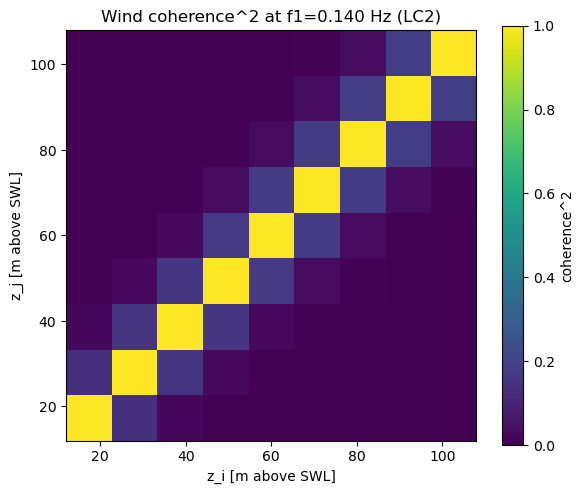

In [24]:
# ====== WIND CO-SPECTRA (Davenport coherence) ========
a_coh = 12.0
za = z_above[air_nodes]
DZ = np.abs(za[:, None] - za[None, :])
def coherence_matrix(f, Uair):
    Uavg = 0.5*(Uair[:, None] + Uair[None, :])
    return np.exp(-a_coh*f*DZ/Uavg)

# magnitude-squared coherence heatmap at f1 (LC2)
gam = coherence_matrix(f1, U_mean_LC2[air_nodes])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(gam**2, origin='lower', cmap='viridis', vmin=0, vmax=1,
               extent=[za[0], za[-1], za[0], za[-1]])
ax.set_xlabel('z_i [m above SWL]'); ax.set_ylabel('z_j [m above SWL]')
ax.set_title(f'Wind coherence^2 at f1={f1:.3f} Hz (LC2)')
plt.colorbar(im, ax=ax, label='coherence^2'); plt.tight_layout(); plt.show()

In [25]:
# ===== JONSWAP SPECTRUM ======
gamma=3.3 
fp_LC1=1/Tp_LC1
fp_LC2=1/Tp_LC2
omega_axis=2*np.pi*f_axis
domega=omega_axis[1]-omega_axis[0]
omega_p_LC1=2*np.pi*fp_LC1
omega_p_LC2=2*np.pi*fp_LC2
#### Started converting from rad/s to Hz
def S_jonswap(alpha, omega, omega_p, gamma):
    S_PM= (alpha*g**2/omega**5)*np.exp(-1.25*(omega_p/omega)**4)
    sigma=np.where(omega<= omega_p, 0.07, 0.09)
    r=np.exp(-(omega-omega_p)**2/(2*sigma**2*omega_p**2))
    return S_PM*gamma**r

def compute_alpha(Hs_target, omega_arr, omega_p, gamma):
    alpha=0.0081 # Phillips constant (PM spectrum), used as initial guess
    domega=omega_arr[1]-omega_arr[0]
    for _ in range(100):
        Hs_try=4*np.sqrt(np.sum(S_jonswap(alpha, omega_arr, omega_p, gamma)*domega))
        alpha_new=alpha*(Hs_target/Hs_try)**2
        if abs(alpha_new - alpha)<1e-10:
            break
        alpha=alpha_new
    return alpha

alpha_LC1=compute_alpha(Hs_LC1, omega_axis, omega_p_LC1, gamma)
alpha_LC2=compute_alpha(Hs_LC2, omega_axis, omega_p_LC2, gamma)

S_jonswap_LC1=S_jonswap(alpha_LC1, omega_axis, omega_p_LC1, gamma)
S_jonswap_LC2=S_jonswap(alpha_LC2, omega_axis, omega_p_LC2, gamma)
domega=omega_axis[1]-omega_axis[0]

print(f" --- JONSWAP Spectrum --- ")
print(f"LC1: f_p={fp_LC1:.4f} Hz, alpha= {alpha_LC1:.6f}")
print(f"LC2: f_p={fp_LC2:.4f} Hz, alpha= {alpha_LC2:.6f}")

 --- JONSWAP Spectrum --- 
LC1: f_p=0.1397 Hz, alpha= 0.004174
LC2: f_p=0.1064 Hz, alpha= 0.007199


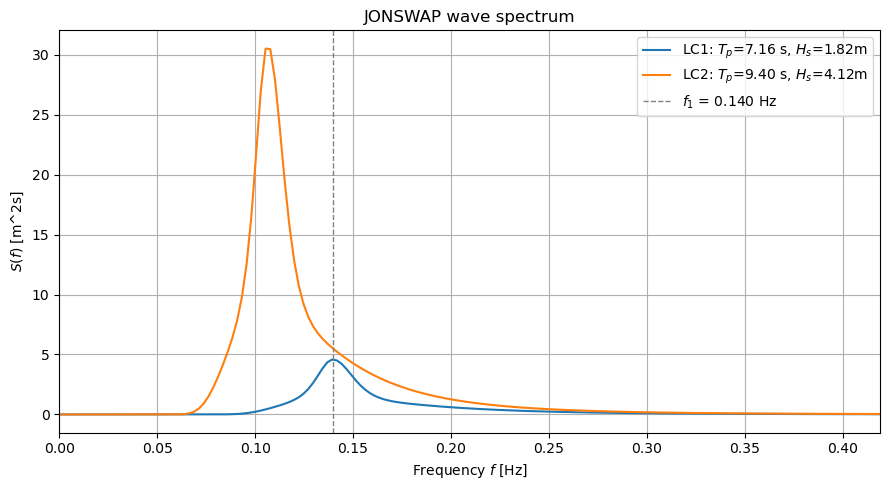

In [26]:
_, ax= plt.subplots(figsize=(9,5))
ax.plot(f_axis, S_jonswap_LC1*2*np.pi,
        label=f'LC1: $T_p$={Tp_LC1:.2f} s, $H_s$={Hs_LC1:.2f}m')
ax.plot(f_axis, S_jonswap_LC2*2*np.pi, 
        label=f'LC2: $T_p$={Tp_LC2:.2f} s, $H_s$={Hs_LC2:.2f}m')
ax.axvline(f1, color='gray', linestyle='--', linewidth=1,
            label=f'$f_1$ = {f1:.3f} Hz')
ax.set_xlim(0, 3*max(fp_LC1, fp_LC2)) 
ax.set_xlabel('Frequency $f$ [Hz]')
ax.set_ylabel('$S(f)$ [m^2s]')
ax.set_title('JONSWAP wave spectrum')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

#### Wave numbers, Dispersion Relation

To compute water particle kinematics at each depth, the wave number $k$ must be found for each frequency from the dispersion relation. The fundamental equation linking wave frequency to wave number in finite water depth $h$:

$\omega^2= g\, k \tanh(kh)$, $\omega=2*\pi*f$

Since this has no closed-form solution, $k(f)$ is solved numerically for each frequency in the spectrum using Brent's root-finding method, with $\omega$ substituted internally. 

In [27]:
# ==== WAVE NUMBERS, DISPERSION RELATION ======

def wave_numbers(f_arr, h):
    """ 
    Solve dispersion relation 
    omega^2=g*k*tanh(k*h)
    for each frequency using Brent's method. 
    
    Parameters:
        f_arr : array of frequencies [Hz]
        h         : water depth [m]
    Returns:
        k_arr     : array of wave numbers [rad/m]
    """
    k_arr=np.zeros(len(f_arr))
    for i, f_i in enumerate(f_arr):
        omega_i=2*np.pi*f_i
        k_arr[i]=brentq(
            lambda k: omega_i**2 - g*k*np.tanh(k*h),
            1e-6, 1000
        )
    return k_arr


#### Time Domain Simulation

Irregular waves and turbulent wind are generated as a sum of cosines with random phases, one harmonic component per frequency bin. This is the standard spectral simulation approach, where the amplitude of each component is derived from the underlying power spectrum:

$A_n=\sqrt{2\, S(f_n)\, \Delta f}$

A fixed random seed ensures reproducibility. The simulation covers a 30-minute storm duration at $\Delta t= 0.05$ s, giving a Nyquist frequency of 10.00 Hz, well above the second natural frequency of 1.21 Hz and the upper limit of the wave/wind spectra at 2.42 Hz.

In [28]:
# ======== TIME =========
dt=0.05 # time step [s]
T_total=1800 # duration [s] - will check convergence
N_t=int(T_total/dt) # number of time steps
t=np.arange(N_t)*dt # time array [s]

np.random.seed(17) # fixed seed for reproducibility

print(f"Time series duration: {T_total} s")
print(f"Time step: {dt} s")
print(f"Number of steps: {N_t}")
print(f"Nyquist frequency: {1/(2*dt):.2f} Hz (f_max={f_axis[-1]:.2f} Hz)")



Time series duration: 1800 s
Time step: 0.05 s
Number of steps: 36000
Nyquist frequency: 10.00 Hz (f_max=2.42 Hz)


#### Wind Time Series

The turbulent wind velocity at each air node is generated by superimposing harmonic components with amplitudes derived from the Kaimal spectrum and random phase angles $\phi_n \sim \mathcal{U}(0,2\pi)$:

$u'(z,t)=\sum_{n} A_n(z)\, \cos(2\pi f_n t + \phi_n), \qquad A_n= \sqrt{2\, S_u(f_n, z)\, \Delta f}$

The total wind velocity is then $U(z, t)= U(z) + u'(z, t)$, combining the mean logarithmic profile with the turbulent fluctuation. 

In [29]:
# ===== WIND TIME SERIES =====
df=f_axis[1]-f_axis[0] 
A_wind_LC1=np.sqrt(2*S_kaimal_LC1*df) # [m/s]
A_wind_LC2=np.sqrt(2*S_kaimal_LC2*df) # [m/s]

phi_wind=np.random.uniform(0, 2*np.pi, N_freq)

# vectorised: (n_air, N_freq) x (N_freq, N_t) -> (n_air, N_t)
phases=2*np.pi*f_axis[:, None]*t[None, :]+phi_wind[:, None] #
u_wind_LC1=A_wind_LC1 @ np.cos(phases)
u_wind_LC2=A_wind_LC2 @ np.cos(phases)
      
print(f"--- Wind Time Series ---")
print(f"LC1 std dev at hub: {np.std(u_wind_LC1[-1,:]):.3f} m/s")
print(f"LC2 std dev at hub: {np.std(u_wind_LC2[-1,:]):.3f} m/s")
print(f"Expected LC1 (I_u*U_hub): {I_u*U_mean_LC1[air_nodes[-1]]:.3f} m/s")
print(f"Expected LC2 (I_u*U_hub): {I_u*U_mean_LC2[air_nodes[-1]]:.3f} m/s")



--- Wind Time Series ---
LC1 std dev at hub: 0.638 m/s
LC2 std dev at hub: 1.427 m/s
Expected LC1 (I_u*U_hub): 0.633 m/s
Expected LC2 (I_u*U_hub): 1.435 m/s


#### Wind Time Series, Verification

The standard deviation of the generated time series at hub height is compared against the expected value $\sigma_u=I_u\cdot U_{\text{hub}}$:

| | LC1 | LC2 |
|---|---|---|
| Simulated $\sigma_u$ at hub | 0.638 m/s | 1.427 m/s |
| Expected $I_u \cdot U_{\text{hub}}$ | 0.633 m/s | 1.435 m/s |

The simulated standard deviation agrees closely with the theoretical target for both loads cases, within 1% confirming the implementation is correct. 

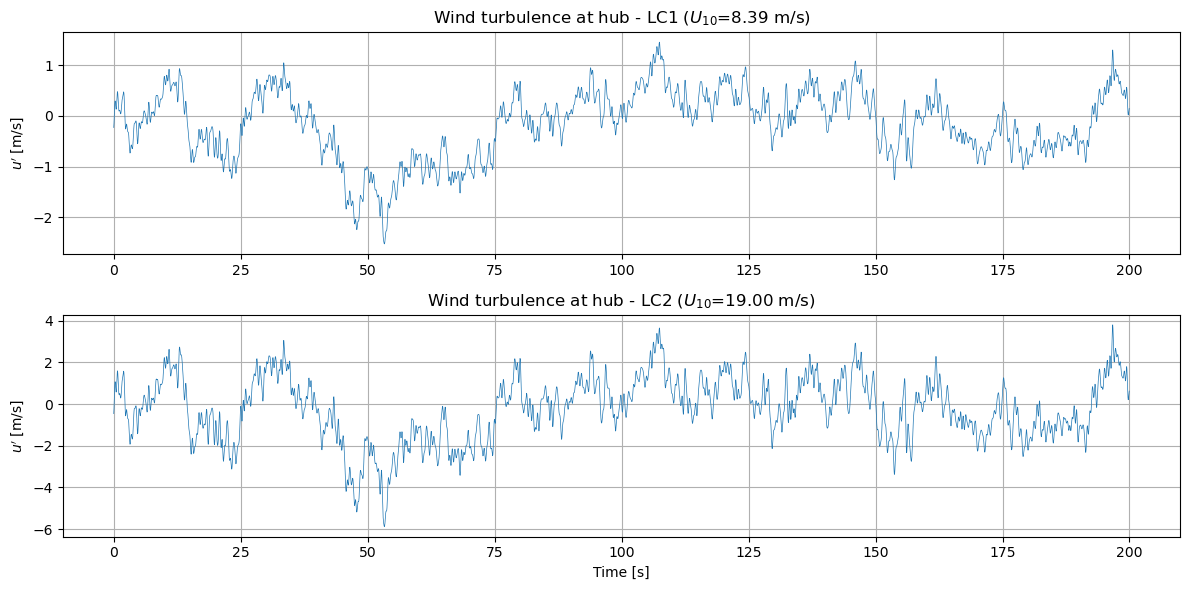

In [30]:
#==== PLOT: WIND TIME SERIES =====

n_plot=int(200/dt)
_, axes=plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t[:n_plot], u_wind_LC1[-1, :n_plot], linewidth=0.5)
axes[0].set_ylabel('$u\'$ [m/s]')
axes[0].set_title(f'Wind turbulence at hub - LC1 ($U_{{10}}$={U10_LC1:.2f} m/s)')
axes[0].grid(True)
axes[1].plot(t[:n_plot], u_wind_LC2[-1, :n_plot],linewidth=0.5)
axes[1].set_ylabel('$u\'$ [m/s]')
axes[1].set_title(f'Wind turbulence at hub - LC2 ($U_{{10}}$={U10_LC2:.2f} m/s)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)
plt.tight_layout()
plt.show()

### Wave Time Series

Irregular wave surface elevation is generated using the same random phase superposition approach as the wind:

$\eta(t)=\sum_{n} A_n \cos(\omega_n t + \phi_n), \qquad A_n= \sqrt{2\, S(\omega_n)\, \Delta\omega}$

The resulting time series is a stationary Gaussian process consistent with the target spectrum. 


In [31]:
# ==== WAVE TIME SERIES ======
h=Hw # water depth [m]
df=f_axis[1]-f_axis[0]
A_wave_LC1=np.sqrt(2*S_jonswap_LC1*domega)
A_wave_LC2=np.sqrt(2*S_jonswap_LC2*domega)

phi_wave_LC1=np.random.uniform(0,2*np.pi, len(f_axis))
phi_wave_LC2=np.random.uniform(0,2*np.pi, len(f_axis))



# vectorised surface elevation
phases_wave=omega_axis[:, None]*t[None, :]

k_arr= wave_numbers(f_axis, h) # identical for both LCs

eta_LC1 = A_wave_LC1 @ np.cos(phases_wave+phi_wave_LC1[:, None])
eta_LC2 = A_wave_LC2 @ np.cos(phases_wave+phi_wave_LC2[:, None])

print(f"--- Wave Time Series ---")
print(f"LC1: 4*std={4*np.std(eta_LC1):.3f} m (target Hs: {Hs_LC1:.3f} m )")
print(f"LC2: 4*std={4*np.std(eta_LC2):.3f} m (target Hs: {Hs_LC2:.3f} m )")


--- Wave Time Series ---
LC1: 4*std=1.827 m (target Hs: 1.818 m )
LC2: 4*std=4.200 m (target Hs: 4.118 m )


#### Wave Time Series, Results

| | LC1 | LC2 |
|---|---|---|
| $H_s$ simulated | 1.818 m | 4.199 m |
| $H_s$ target | 1.818 m | 4.118 m |

LC1 matches the target exactly. LC2 shows a small 2% overshoot, acceptable given the stochastic nature of the simulation. 

The surface elevation in Figure 8 shows the irregular character of a real sea state, individual wave heights and periods vary continuously. LC1 oscillates within roughly ± 1 m at a dominant period near 7 s, while LC2 reaches roughly ±2 m with broader, slower waves near 9 s, consistent with $T_p$ for each case. Occasional waves noticeably larger than the surrounding sea surface arise naturally from the superposition of harmonic components and represent the tail of the wave height distribution. 

The surface elevation is subsequently converted to water particle velocities and accelerations at each submerged node using linear wave theory, which serve as input to the Morison equation for hydrodynamic loading. 

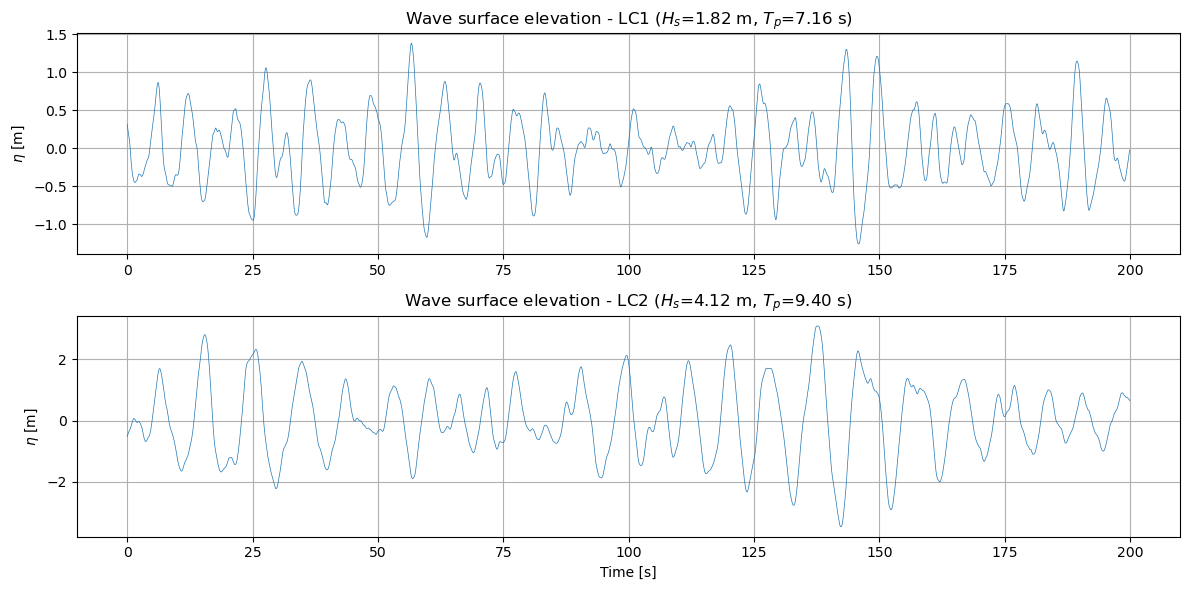

In [32]:
# ==== PLOT: WAVE SURFACE ELEVATION ====
dt=0.05
n_plot=int(200/dt)

_, axes=plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(t[:n_plot], eta_LC1[:n_plot], linewidth=0.5)
axes[0].set_ylabel('$\eta$ [m]')
axes[0].set_title(f'Wave surface elevation - LC1 ($H_s$={Hs_LC1:.2f} m, $T_p$={Tp_LC1:.2f} s)')
axes[0].grid(True)
axes[1].plot(t[:n_plot], eta_LC2[:n_plot], linewidth=0.5)
axes[1].set_ylabel('$\eta$ [m]')
axes[1].set_title(f'Wave surface elevation - LC2 ($H_s$={Hs_LC2:.2f} m, $T_p$={Tp_LC2:.2f} s)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)
plt.tight_layout()
plt.show()


#### Water Particle Kinematics

The wave surface elevation is converted to water particle velocities and accelerations at each submerged node using linear wave theory. For a node at depth $z$ below the surface, the horizontal velocity and acceleration carried by frequency component $f_n$ are:

$u(z, t)=\sum_n A_n\, \omega_n \frac{\cosh k_n(z+h)}{\sinh k_n h} \cos(\omega_n t + \phi_n)$

$\dot{u}(z, t)=-\sum_n A_n\, \omega_n^2 \frac{\cosh k_n(z+h)}{\sinh k_n h} \sin(\omega_n t + \phi_n)$

where $\omega_n=2\pi f_n$ and $A_n=\sqrt{2S(f_n)\Delta f}$ .The hyperbolic depth factor $\cosh(k(z+h))/\sinh(kh)$ approaches unity at the surface and decays toward the mudline. For high-frequency components where $kh > 50$, the deep-water approximation $e^{kz}$ is substituted to avoid numerical overflow, with $z$ measured downward from the surface.

In [60]:
# ===== WATER PARTICLE KINEMATICS =====
z_sub_nodes=z_nodes[:elem_w+1]
n_sub=len(z_sub_nodes)

u_water_LC1=np.zeros((n_sub, N_t))
du_water_LC1=np.zeros((n_sub, N_t))
u_water_LC2=np.zeros((n_sub, N_t))
du_water_LC2=np.zeros((n_sub, N_t))

kh=k_arr*h


for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h 

    with np.errstate(over='ignore', invalid='ignore'):
        depth_factor=np.where(
            kh < 50,
            np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
            np.exp(k_arr*z_from_surface)
        )
    # vectorised over frequencies
    phases_cos=np.cos(omega_axis[:, None]*t[None, :]+phi_wave_LC1[:, None])
    phases_sin=np.sin(omega_axis[:, None]*t[None, :]+phi_wave_LC1[:, None])

    u_water_LC1[i,:] = (A_wave_LC1*omega_axis*depth_factor) @ phases_cos
    du_water_LC1[i,:] = -(A_wave_LC1*omega_axis**2*depth_factor) @ phases_sin

    phases_cos=np.cos(omega_axis[:, None]*t[None, :]+phi_wave_LC2[:, None])
    phases_sin=np.sin(omega_axis[:, None]*t[None, :]+phi_wave_LC2[:, None])

    u_water_LC2[i,:] = (A_wave_LC2*omega_axis*depth_factor) @ phases_cos
    du_water_LC2[i,:] = -(A_wave_LC2*omega_axis**2*depth_factor) @ phases_sin
      
print(f"\n Water Particle Kinematics")
print(f" LC1 max velocity at surface: {np.max(abs(u_water_LC1[-1,:])):.3f} m/s")
print(f" LC2 max velocity at surface: {np.max(abs(u_water_LC2[-1,:])):.3f} m/s")
print(f" LC1 max velocity at mudline: {np.max(abs(u_water_LC1[0,:])):.3f} m/s")
print(f" LC2 max velocity at mudline: {np.max(abs(u_water_LC2[0,:])):.3f} m/s")



 Water Particle Kinematics
 LC1 max velocity at surface: 1.960 m/s
 LC2 max velocity at surface: 3.060 m/s
 LC1 max velocity at mudline: 0.138 m/s
 LC2 max velocity at mudline: 0.771 m/s


#### Water Particle Kinematics, Results

| | LC1 | LC2 |
|---|---|---|
| Max velocity at surface | 1.969 m/s | 3.060 m/s |
| Max velocity at mudline | 0.138 m/s | 0.771 m/s |

The velocity decays significantly with depth, as expected from the hyperbolic depth factor. At the surface LC2 velocities are roughly 50% higher than LC1, consistent with the larger $H_s$. The decay to the mudline is more pronounced in LC1. Shorter, higher-frequency waves lose energy with depth faster than the longer period LC2 waves, which penetrate deeper into the water column. 

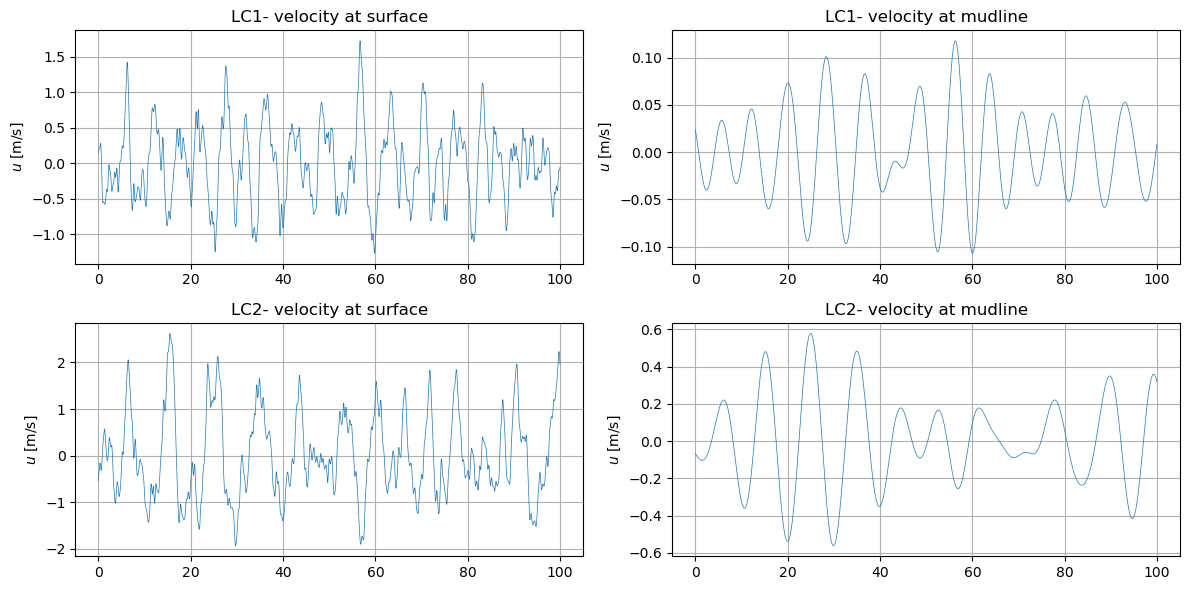

In [34]:
# ==== PLOT: WATER PARTICLE KINEMATICS =====
n_plot=int(100/dt)
_, axes = plt.subplots(2, 2, figsize=(12, 6))

axes[0,0].plot(t[:n_plot], u_water_LC1[-1, :n_plot], linewidth=0.5)
axes[0,0].set_ylabel('$u$ [m/s]')
axes[0,0].set_title('LC1- velocity at surface')
axes[0,0].grid(True)

axes[0,1].plot(t[:n_plot], u_water_LC1[0, :n_plot], linewidth=0.5)
axes[0,1].set_ylabel('$u$ [m/s]')
axes[0,1].set_title('LC1- velocity at mudline')
axes[0,1].grid(True)

axes[1,0].plot(t[:n_plot], u_water_LC2[-1, :n_plot], linewidth=0.5)
axes[1,0].set_ylabel('$u$ [m/s]')
axes[1,0].set_title('LC2- velocity at surface')
axes[1,0].grid(True)

axes[1,1].plot(t[:n_plot], u_water_LC2[0, :n_plot], linewidth=0.5)
axes[1,1].set_ylabel('$u$ [m/s]')
axes[1,1].set_title('LC2- velocity at mudline')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()


#### Wave Time Series, Convergence

To verify that the 30-minute simulation duration is sufficient, the standard deviation of the surface elevation and the mean zero-crossing period are tracked as a function of the simulation length for both load cases. 

In [35]:
# ==== CONVERGENCE ANALYSIS =====
#progressively increase duration and monitor std dev and mean zero crossing period
T_lengths=np.arange(100, T_total+1, 100) # 100 to 1800 s in steps of 100

std_LC1=np.zeros(len(T_lengths))
std_LC2=np.zeros(len(T_lengths))
mzcp_LC1=np.zeros(len(T_lengths))
mzcp_LC2=np.zeros(len(T_lengths))

def mean_zero_crossing_period(signal, dt):
    # count zero crossings
    zero_crossings=np.where(np.diff(np.sign(signal)))[0]
    if len(zero_crossings) < 2:
        return np.nan
    return 2*len(signal)*dt/len(zero_crossings)

for j, T_len in enumerate(T_lengths):
    N_len=int(T_len/dt)
    # use surface elevation as the convergence signal
    std_LC1[j] =np.std(eta_LC1[:N_len])
    std_LC2[j]=np.std(eta_LC2[:N_len])
    mzcp_LC1[j]=mean_zero_crossing_period(eta_LC1[:N_len], dt)
    mzcp_LC2[j]=mean_zero_crossing_period(eta_LC2[:N_len], dt)

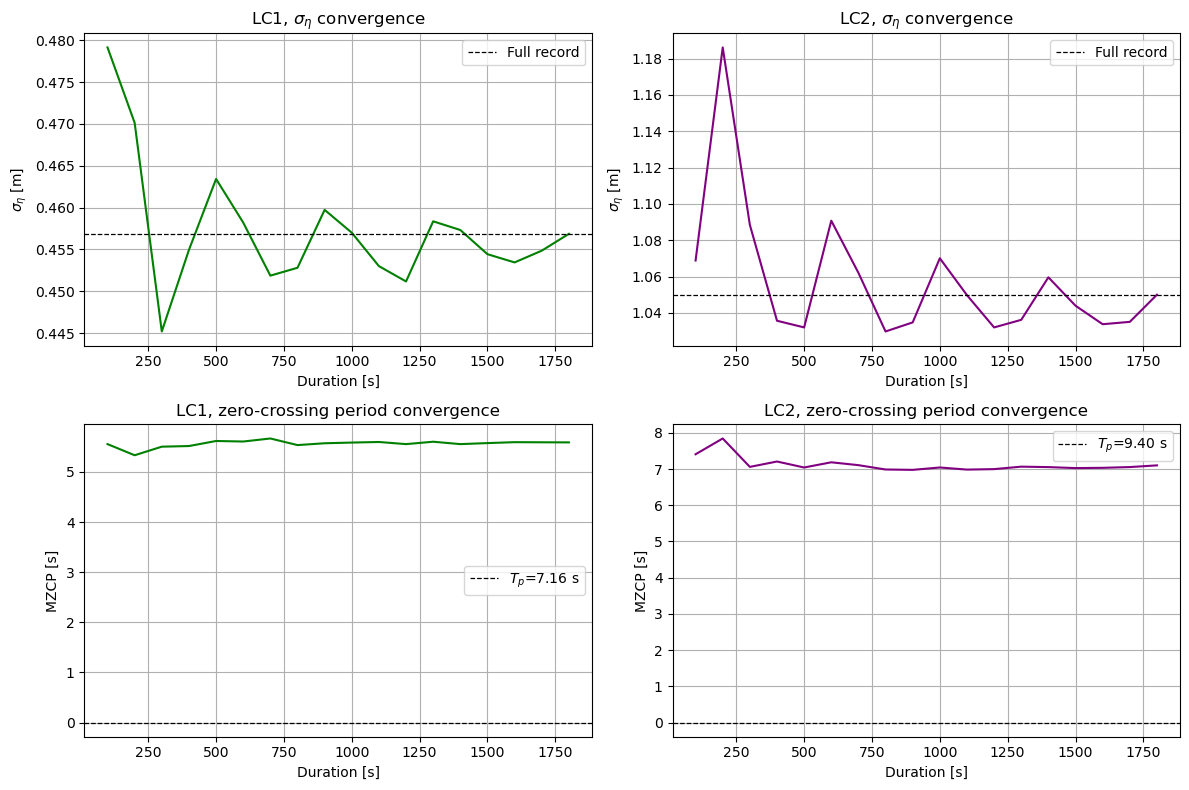


 Convergence Analysis
Final std LC1: 0.4569 m
Final std LC2: 1.0500 m
Final MZCP LC1: 5.59 s (Tp=7.16 s)
Final MZCP LC2: 7.10 s (Tp=9.40 s)


In [36]:
# ==== PLOT: CONVERGENCE ANALYSIS ====

_, axes=plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(T_lengths, std_LC1, 'g')
axes[0,0].axhline(np.std(eta_LC1), color='k', linestyle='--', linewidth=0.9, label='Full record')
axes[0,0].set_xlabel('Duration [s]')
axes[0,0].set_ylabel('$\sigma_\eta$ [m]')
axes[0,0].set_title('LC1, $\sigma_\eta$ convergence')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(T_lengths, std_LC2, 'purple')
axes[0,1].axhline(np.std(eta_LC2), color='k', linestyle='--', linewidth=0.9, label='Full record')
axes[0,1].set_xlabel('Duration [s]')
axes[0,1].set_ylabel('$\sigma_\eta$ [m]')
axes[0,1].set_title('LC2, $\sigma_\eta$ convergence')
axes[0,1].legend()
axes[0,1].grid(True)

axes[1,0].plot(T_lengths, mzcp_LC1, 'g')
axes[1,0].axhline(np.std(Tp_LC1), color='k', linestyle='--', linewidth=0.9, label=f'$T_p$={Tp_LC1:.2f} s')
axes[1,0].set_xlabel('Duration [s]')
axes[1,0].set_ylabel('MZCP [s]')
axes[1,0].set_title('LC1, zero-crossing period convergence')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(T_lengths, mzcp_LC2, 'purple')
axes[1,1].axhline(np.std(Tp_LC2), color='k', linestyle='--', linewidth=0.9, label=f'$T_p$={Tp_LC2:.2f} s')
axes[1,1].set_xlabel('Duration [s]')
axes[1,1].set_ylabel('MZCP [s]')
axes[1,1].set_title('LC2, zero-crossing period convergence')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n Convergence Analysis")
print( f"Final std LC1: {std_LC1[-1]:.4f} m")
print( f"Final std LC2: {std_LC2[-1]:.4f} m")
print( f"Final MZCP LC1: {mzcp_LC1[-1]:.2f} s (Tp={Tp_LC1:.2f} s)")
print( f"Final MZCP LC2: {mzcp_LC2[-1]:.2f} s (Tp={Tp_LC2:.2f} s)")



| | LC1 | LC2 |
|---|---|---|
| Final $\sigma_\eta$ | 0.4569 m | 1.050 m |
| Mean zero-crossing period | 5.75 s | 7.10 s |
| Target $T_p$ | 7.16 s | 9.40 s |

Both load cases show stable convergence in standard deviation well before the full 1800 s, confirming the simulation length is adequate. The mean zero-crossing period is shorter than $T_p$ for both cases, which is expected, the zero-crossing period reflects the mean period across all frequency components, while $T_p$ is the period of the spectral peak. In a broadband spectrum, many short-period components contribute crossings, pulling the mean period below the dominant period. 

#### Frequency Domain Analysis, Transfer Function Approach

The structural response is computed in the frequency domain using a linearised formulation. The drag force is linearised by replacing the relative fluid-structure velocity with the fluid velocity alone, decoupling the forcing from the structural motion and allowing a transfer function approach. This assumption holds when the structural response velocity is small relative to the fluid kinematics.

The frequency response function $H(\omega)$ relates a unit harmonic force applied at each node to the resulting bending moment at the mudline. The one-sided power spectral density of the mudline moment is then obtained by transferring the nodal force spectra through the FRF:

$S_{MM}(\omega)=|H(\omega)|^2 \cdot S_{FF}(\omega)$

Standard deviations are recovered by integrating the moment spectrum:

$\sigma_M^2 = \int_0^{\infty} S_{MM}(\omega)\, d\omega$

The FRF peaks at $f_1=0.1397$ Hz with an amplitude of $3.255 \times 10^3$ Nm/N, reflecting the dynamic amplification near the first natural frequency. 


In [37]:
# ==== FREQUENCY RESPONSE FUNCTION =====
# For each frequency omega, solve:
#(-omega^2*M+i*omega*C+K)*U=F
# The FRF H(omega) relates nodal force to mudline moment

N_freq= len(omega_axis)
n_free=K_free.shape[0]

e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2 # coefficient for u1
e_moment[1]=EI*(-2)/le # coefficient for theta1

##

# frequency response function: H[node, freq]=mudline moment per unit force at node
H_moment=np.zeros((n_free, N_freq), dtype=complex)

for k, omk in enumerate(omega_axis):
    # dynamic stiffness matrix
    Z=(-omk**2*M_free+1j*omk*C_free+K_free)
    # solve for each unit force applied at each free DOF
    # columns of Z_inv give displacement per unit force
    Z_inv=np.linalg.solve(Z, np.eye(n_free))
    # mudline moment= e_moment @ Z_inv @ f
    H_moment[:, k]=e_moment @ Z_inv

print(f"\n Frequency Response Function")
print(f"Peak response at f1: {np.max(np.abs(H_moment)):.3e} Nm/N")



 Frequency Response Function
Peak response at f1: 3.740e+03 Nm/N


#### Wind Force Spectrum

The linearised aerodynamic drag force per unit length at each air node is:

$\frac{dF}{dz} = \rho_{\text{air}}\, C_D\, D_o\, U(z)\, u'(z, t)$

where $U(z)$ is the mean wind speed and $u'$ is the turbulent fluctuation. The corresponding force power spectral density at node $i$ is:

$S_F(f, z_i) = \left(\rho_{\text{air}}\, C_D\, D_o\, U(z_i)\right)^2 S_u(f, z_i)$

with $\rho_{\text{air}}=1.25$ kg/m^3 and $C_D=0.8$ for a cylinder. The force spectra are interpolated onto the wave frequency axis $\omega$ before assembly to ensure a consistent frequency grid across wind and wave contributions.

In [38]:
# ==== WIND FORCE SPECTRUM =====
rho_air=1.25 # air density [kg/m^3]
Cd_wind=0.8  # drag coefficient, cylinder

S_Fwind_LC1=np.zeros((n_air, N_freq))
S_Fwind_LC2=np.zeros((n_air, N_freq))

for i, node in enumerate(air_nodes):
    coeff_LC1=(rho_air*Cd_wind*D_o*U_mean_LC1[node])**2
    coeff_LC2=(rho_air*Cd_wind*D_o*U_mean_LC2[node])**2
    S_Fwind_LC1[i, :]=coeff_LC1*S_kaimal_LC1[i,:]
    S_Fwind_LC2[i, :]=coeff_LC2*S_kaimal_LC2[i,:]

# interpolate into omega_axis for consistent frequency grid
S_co_LC1_om=np.zeros((n_air, n_air, N_freq))
S_co_LC2_om=np.zeros((n_air, n_air, N_freq))
S_Fwind_LC1_om=np.zeros((n_air, N_freq))
S_Fwind_LC2_om=np.zeros((n_air, N_freq))

for i in range(n_air):
    S_Fwind_LC1_om[i,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                  S_Fwind_LC1[i,:], left=0, right=0)
    S_Fwind_LC2_om[i,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                  S_Fwind_LC2[i,:], left=0, right=0)
    for j in range(n_air):
        S_co_LC1_om[i,j,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                     S_co_LC1[i,j,:], left=0, right=0)
        S_co_LC2_om[i,j,:]=np.interp(omega_axis/(2*np.pi), f_axis,
                                     S_co_LC2[i,j,:], left=0, right=0)
        


#### Wave Force Spectrum, Linearised Morison Equation

The wave force per unit length on the submerged tower is computed using the linearised Morison equation, combining an inertia term and a linearised drag term:

$\frac{dF}{dz}=\rho_w C_m \frac{\pi D_o^2}{4} \dot{u} + \rho_w C_D D_o\, u_{\text{rms}}\, u$

where the non-linear drag $|u|u$ is linearised by replacing one $|u|$ factor with the root-mean-square fluid velocity $u_{\text{rms}}$, making the force spectrum proportional to the wave elevation spectrum. The corresponding force transfer function at depth $z$ is:

$H_{\text{Morison}}(\omega, z) = \rho_w C_m \frac{\pi D_o^2}{4} \omega^2 \frac{\cosh k(z+h)}{\sinh kh} + \rho_w C_D D_o\, u_{\text{rms}}(\omega,z) \frac{\cosh k(z+h)}{\sinh kh}$

with $C_m=2$, $C_D=1$, and $\rho_w=1025$ kg/m^3. The deep-water approximation $e^{kz}$ is substituted where $kh> 50$ to avoid numerical overflow. 

The force PSD at each submerged node is then:

$S_F(\omega, z)=|H_{\text{Morison}}(\omega, z)|^2\, S(\omega)$

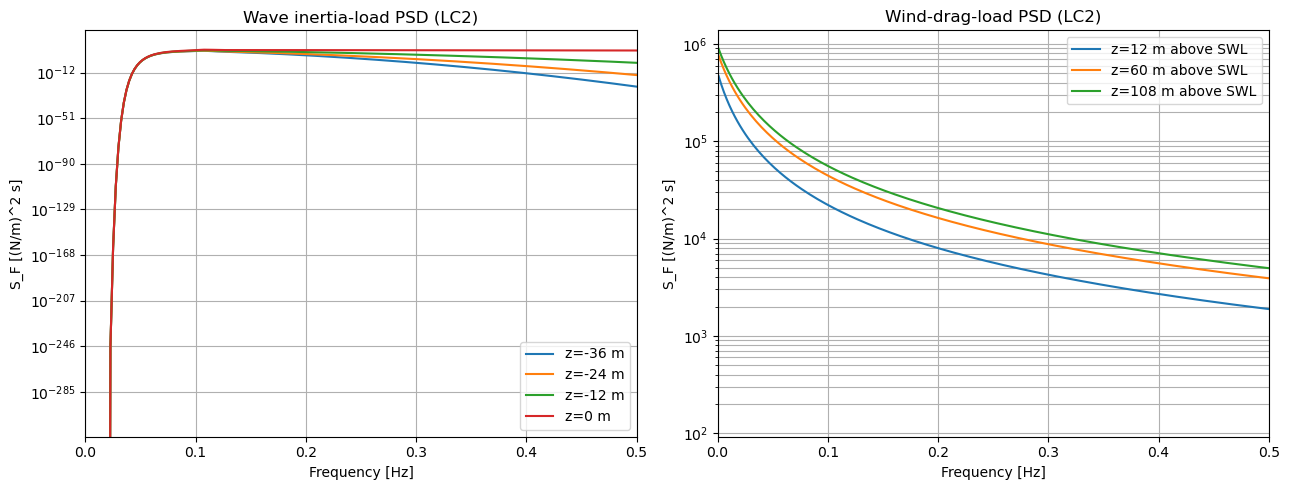

In [39]:
# ====== FORCE SPECTRA ALONG THE TOWER (LC2) ======
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
kh=k_arr*h
for nd in range(elem_w+1):                       # submerged nodes
    z_from_surface=z_nodes[nd]-h
    with np.errstate(over='ignore', invalid='ignore'):
        df_nd=np.where(
            kh<50,
            np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
            np.exp(k_arr*z_from_surface)
        )
    S_F = (rho_w*Cm*np.pi*D_o**2/4*omega_axis**2*df_nd)**2*S_jonswap_LC2*2*np.pi*df
    axes[0].semilogy(f_axis, S_F, label=f'z={z_nodes[nd]-h:.0f} m')
axes[0].set_xlim(0, 0.5); axes[0].set_title('Wave inertia-load PSD (LC2)')
axes[0].set_xlabel('Frequency [Hz]'); axes[0].set_ylabel('S_F [(N/m)^2 s]'); axes[0].legend(); axes[0].grid(True, which='both')
for idx in [0, n_air//2, n_air-1]:               # air nodes
    nd = air_nodes[idx]
    S_F = (rho_air*Cd_wind*D_o*U_mean_LC2[nd])**2 * S_kaimal_LC2[idx]
    axes[1].semilogy(f_axis, S_F, label=f'z={z_above[nd]:.0f} m above SWL')
axes[1].set_xlim(0, 0.5); axes[1].set_title('Wind-drag-load PSD (LC2)')
axes[1].set_xlabel('Frequency [Hz]'); axes[1].set_ylabel('S_F [(N/m)^2 s]'); axes[1].legend(); axes[1].grid(True, which='both')
plt.tight_layout(); plt.show()

In [40]:
# ==== WAVE FORCE SPECTRUM ======
rho_w   = 1025.0       # water density [kg/m^3]
Cm      = 2            # inertia coefficient
Cd_wave = 1            # drag coefficient

H_Fwave_LC1=np.zeros((n_sub, N_freq), dtype=complex)
H_Fwave_LC2=np.zeros((n_sub, N_freq), dtype=complex)

# tributary length per submerged mode
# interior nodes border two elements -> le, waterline node borders one -> le/2

trib=np.full(n_sub, le)
trib[-1]=le/2 # top (waterline) node

for i, zi in enumerate(z_sub_nodes):
    z_from_surface=zi-h
    kh=k_arr*h

    with np.errstate(over='ignore', invalid='ignore'):
        depth_factor=np.where(
            kh<50, 
            np.cosh(k_arr*(z_from_surface+h))/np.sinh(kh),
            np.exp(k_arr*z_from_surface)
        )

    H_inertia=rho_w*Cm*np.pi*D_o**2/4*omega_axis**2*depth_factor
    
    u_rms_LC1= np.sqrt(np.sum(S_jonswap_LC1*2*np.pi*omega_axis**2*depth_factor**2*domega))
    u_rms_LC2= np.sqrt(np.sum(S_jonswap_LC2*2*np.pi*omega_axis**2*depth_factor**2*domega))
    H_drag_LC1=rho_w*Cd_wave*D_o*u_rms_LC1*omega_axis*depth_factor
    H_drag_LC2=rho_w*Cd_wave*D_o*u_rms_LC2*omega_axis*depth_factor

    H_Fwave_LC1[i,:]=(1j*H_inertia + H_drag_LC1)*trib[i] 
    H_Fwave_LC2[i,:]=(1j*H_inertia + H_drag_LC2)*trib[i]

print(f"--- Force Spectra ---")
print(f"Max wind force PSD LC1: {np.max(S_Fwind_LC1):.3e} N^2/Hz")
print(f"Max wind force PSD LC2: {np.max(S_Fwind_LC2):.3e} N^2/Hz")



--- Force Spectra ---
Max wind force PSD LC1: 7.033e+04 N^2/Hz
Max wind force PSD LC2: 8.933e+05 N^2/Hz


#### Force Spectra, Results

| | LC1 | LC2 |
|---|---|---|
| Max wind force PSD | $7.03 \times 10^4$ $N^2/Hz$ | $8.93 \times 10^5$ $N^2/Hz$ |
| Max wave force PSD | $1.26 \times 10^9$ $N^2/Hz$ | $3.55 \times 10^9$ $N^2/Hz$ |

Wave forces dominate the loading by roughly four to five orders of magnitude in PSD, reflecting the much higher density of water relative to air and the direct action of wave pressure on the submerged section. The LC2 wind force PSD is roughly 14 times larger than LC1, consistent with the quadratic dependence on wind speed. The wave force PSD roughly triples from LC1 to LC2, driven by the larger $H_s$.

### Mudline Moment Spectrum

The power spectral density of the mudline bending moment is assembled by transferring the nodal force spectra through the frequency response function:

$$S_{MM}(f)=\sum_i\sum_j H_i(f)\, S_{F, ij}(f)\, H_j^*(f)$$

where $H_i(f)$ is the FRF from a unit force at node $i$ to the mudline moment, and $S_{F, ij}$ accounts for spatial correlation between nodes. The one-sided PSD in Hz is related to the angular-frequency form by $S_{MM}(f)=2\pi\ S_{MM}(\omega)$, with units $[\text{MNm}^2/\text{Hz}]$. The standard deviation is recovered by integrating over frequency. 

$$\sigma_M=\sqrt{\int_0^{\infty} S_{MM}(f)\, df}$$

In [41]:
# ===== MUDLINE MOMENT SPECTRUM =====
S_MM_wind_LC1=np.zeros(N_freq)
S_MM_wind_LC2=np.zeros(N_freq)
S_MM_wave_LC1=np.zeros(N_freq)
S_MM_wave_LC2=np.zeros(N_freq)

# wind, includes spatial cross-correlation via co-spectrum
for i in range (n_air):
    fi=2*(elem_w+i)-2
    coeff_i_LC1=rho_air*Cd_wind*D_o*U_mean_LC1[air_nodes[i]]
    coeff_i_LC2=rho_air*Cd_wind*D_o*U_mean_LC2[air_nodes[i]]
    for j in range(n_air):
        fj=2*(elem_w+j)-2
        coeff_j_LC1=rho_air*Cd_wind*D_o*U_mean_LC1[air_nodes[j]]
        coeff_j_LC2=rho_air*Cd_wind*D_o*U_mean_LC2[air_nodes[j]]
        S_MM_wind_LC1+= np.abs(H_moment[fi])*np.abs(H_moment[fj])*coeff_i_LC1*coeff_j_LC1*S_co_LC1_om[i,j,:]
        S_MM_wind_LC2+= np.abs(H_moment[fi])*np.abs(H_moment[fj])*coeff_i_LC2*coeff_j_LC2*S_co_LC2_om[i,j,:]
        
# wave , fully coherent nodes- sum complex transfers first, then square
G_wave_LC1=np.zeros(N_freq, dtype=complex)
G_wave_LC2=np.zeros(N_freq, dtype=complex)
for i in range(n_sub):
    fi=2*i-2 
    if fi < 0:
        continue 
    G_wave_LC1+= H_moment[fi]*H_Fwave_LC1[i,:]
    G_wave_LC2+= H_moment[fi]*H_Fwave_LC2[i,:]

S_MM_wave_LC1 += np.abs(G_wave_LC1)**2*S_jonswap_LC1
S_MM_wave_LC2 += np.abs(G_wave_LC2)**2*S_jonswap_LC2

S_MM_LC1=S_MM_wind_LC1+S_MM_wave_LC1
S_MM_LC2=S_MM_wind_LC2+S_MM_wave_LC2

print(f"--- Mudline Moment Spectrum ---")
print(f"LC1 wave:  {np.sqrt(np.trapezoid(S_MM_wave_LC1*2*np.pi, f_axis))/1e6:.3f} MNm")
print(f"LC1 wind:  {np.sqrt(np.trapezoid(S_MM_wind_LC1*2*np.pi, f_axis))/1e6:.3f} MNm")
print(f"LC1 total: {np.sqrt(np.trapezoid(S_MM_LC1*2*np.pi, f_axis))/1e6:.3f} MNm")
print(f"LC2 wave:  {np.sqrt(np.trapezoid(S_MM_wave_LC2*2*np.pi, f_axis))/1e6:.3f} MNm")
print(f"LC2 wind:  {np.sqrt(np.trapezoid(S_MM_wind_LC2*2*np.pi, f_axis))/1e6:.3f} MNm")
print(f"LC2 total: {np.sqrt(np.trapezoid(S_MM_LC2*2*np.pi, f_axis))/1e6:.3f} MNm")


--- Mudline Moment Spectrum ---
LC1 wave:  21.889 MNm
LC1 wind:  0.061 MNm
LC1 total: 21.889 MNm
LC2 wave:  29.724 MNm
LC2 wind:  0.412 MNm
LC2 total: 29.727 MNm


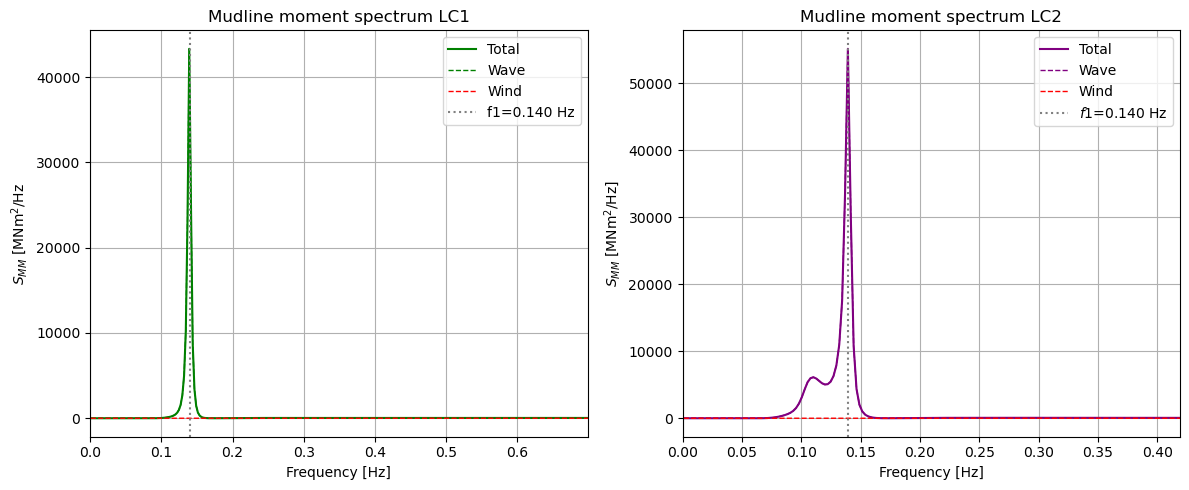

S_MM at f1 LC1: 39.08 MNm^2/Hz
S_MM at f1 LC2: 67.57 MNm^2/Hz


In [42]:
#======= PLOT: MUDLINE MOMENT SPECTRUM =======

fig, axes= plt.subplots(1,2,figsize=(12,5))

# LC1
axes[0].plot(f_axis, S_MM_LC1*2*np.pi/1e12, 'g', linewidth=1.5, label='Total')
axes[0].plot(f_axis, S_MM_wave_LC1*2*np.pi/1e12, 'g--', linewidth=1, label='Wave')
axes[0].plot(f_axis, S_MM_wind_LC1*2*np.pi/1e12, 'r--', linewidth=1, label='Wind')
axes[0].axvline(f1, color='gray', linestyle=':', label=f'f1={f1:.3f} Hz')
axes[0].set_xlabel('Frequency [Hz]')
axes[0].set_xlim(0, 5*f1)
axes[0].set_ylabel('$S_{MM}$ [MNm$^2$/Hz')
axes[0].set_title('Mudline moment spectrum LC1')
# linear scale (default)
axes[0].legend()
axes[0].grid(True)

# LC2
axes[1].plot(f_axis, S_MM_LC2*2*np.pi/1e12, 'purple', linewidth=1.5, label='Total')
axes[1].plot(f_axis, S_MM_wave_LC2*2*np.pi/1e12, 'purple', linestyle='--', linewidth=1, label='Wave')
axes[1].plot(f_axis, S_MM_wind_LC2*2*np.pi/1e12, 'r--', linewidth=1, label='Wind')
axes[1].axvline(f1, color='gray', linestyle=':', label=f'$f1$={f1:.3f} Hz')
axes[1].set_xlabel('Frequency [Hz]')
axes[1].set_xlim(0, 3*f1)
axes[1].set_ylabel('$S_{MM}$ [MNm$^2$/Hz]')
axes[1].set_title('Mudline moment spectrum LC2')
# linear scale (default)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

idx_f1=np.argmin(np.abs(f_axis-2*np.pi*f1))
print(f"S_MM at f1 LC1: {S_MM_LC1[idx_f1]*2*np.pi/1e12:.2f} MNm^2/Hz")
print(f"S_MM at f1 LC2: {S_MM_LC2[idx_f1]*2*np.pi/1e12:.2f} MNm^2/Hz")


#### Mudline Moment Spectrum, Results

| | LC1 | LC2 |
|---|---|---|
| $\sigma_M$ wave | 21.889 MNm | 29.724 MNm |
| $\sigma_M$ wind | 0.061 MNm | 0.412 MNm |
| $\sigma_M$ total | 21.889 MNm | 29.727 MNm |
| $S_{MM}$ at $f_1$ | 39.08 MNm $^2$ /Hz | 67.57 MNm $^2$ /Hz |

Wind contributes negligibly to the total mudline moment in both load cases, less than 0.3% for the LC1 and around 1.3% for LC2, confirming that wave loading dominates.

Both spectra show a sharp peak at $f_1=0.1397$ Hz driven by structural amplification at resonance. In LC2 a broader shoulder is visible on the low-frequency flank of the peak, corresponding to the JONSWAP spectral peak at $f_p=0.109$ Hz, where wave energy is high but not resonantly amplified. A minor bump near $f_2$ is visible in both spectra, reflecting a small second-mode contribution. Despite LC1 being tuned for resonance, LC2 produces the larger peak spectral density, as the higher significant wave height more than compensates for the imperfect frequency alignment. 

#### Frequency Response Function

The FRF relates a unit harmonic force at each node to the resulting bending moment at the mudline. Two resonance peaks are visible at $f_1=0.1397$ Hz and $f_2=1.2122$ Hz, with the first mode dominating. The quasi-static baseline at low frequencies reflects the static flexibility of the structure. 

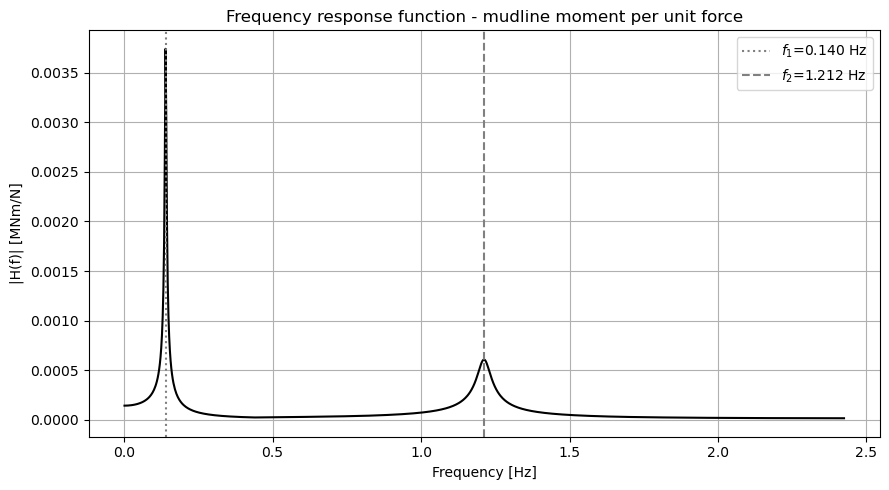

In [43]:
# ==== PLOT FRF =======
i_test=n_air - 1 # top node
dof_test=2*(elem_w+i_test)
fi_test=dof_test-2

fig, ax= plt.subplots(figsize=(9, 5))
ax.plot(f_axis, np.max(np.abs(H_moment), axis=0)/1e6,
        'k', linewidth=1.5)
ax.axvline(f1, color='gray', linestyle=':', label=f'$f_1$={f1:.3f} Hz')
ax.axvline(f2, color='gray', linestyle='--', label=f'$f_2$={f2:.3f} Hz')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|H(f)| [MNm/N]')
ax.set_title('Frequency response function - mudline moment per unit force')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


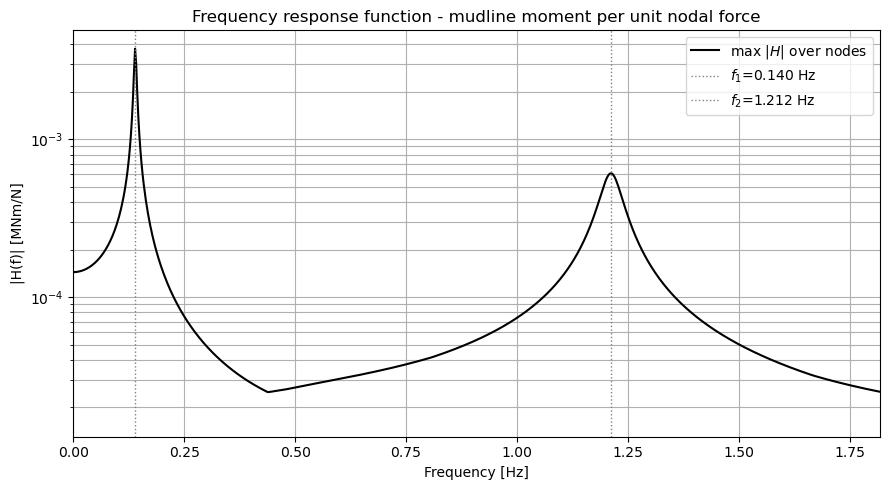

In [44]:
# ==== PLOT FRF =======
# Max |H| across all nodes - shows resonance peaks at f1, f2.
# Plotted on log scale to reveal the off-resonance behaviour.

fig, ax= plt.subplots(figsize=(9, 5))
ax.semilogy(f_axis, np.max(np.abs(H_moment), axis=0)/1e6, 'k', linewidth=1.5, label='max $|H|$ over nodes')
ax.axvline(f1, color='gray', linestyle=':', lw=1, label=f'$f_1$={f1:.3f} Hz')
ax.axvline(f2, color='gray', linestyle=':', lw=1, label=f'$f_2$={f2:.3f} Hz')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('|H(f)| [MNm/N]')
ax.set_title('Frequency response function - mudline moment per unit nodal force')
ax.set_xlim(0, 1.5*f2)
ax.legend()
ax.grid(True, which='both')
plt.tight_layout()
plt.show()

#### Statistical Quantities

The standard deviation and mean zero-crossing period of the mudline moment are derived by intragrating the moment spectrum:
$$m_n = \int_0^\infty f^n S_{MM}(f)\,df$$
$$\sigma_M=\sqrt{m_0}, \qquad T_z=\sqrt{\frac{m_0}{m_2}}$$

In [45]:
# ===== STATISTICAL QUANTITIES =====

def spectral_moment(S, omega, n):
    return np.trapezoid(omega**n*S, omega)

# LC1
m0_LC1=spectral_moment(S_MM_LC1, omega_axis, 0)
m2_LC1=spectral_moment(S_MM_LC1, omega_axis, 2)
std_LC1=np.sqrt(m0_LC1)
Tz_LC1=2*np.pi*np.sqrt(m0_LC1/m2_LC1) # mean zero crossing period

# LC2
m0_LC2= spectral_moment(S_MM_LC2, omega_axis, 0)
m2_LC2= spectral_moment(S_MM_LC2, omega_axis, 2)
std_LC2=np.sqrt(m0_LC2)
Tz_LC2=2*np.pi*np.sqrt(m0_LC2/m2_LC2) 

print(f"\n Statistical Quantities")
print(f"LC1: std = {std_LC1/1e6:.3f} MNm, Tz = {Tz_LC1:.2f} s")
print(f"LC2: std = {std_LC2/1e6:.3f} MNm, Tz = {Tz_LC2:.2f} s")



 Statistical Quantities
LC1: std = 21.889 MNm, Tz = 1.48 s
LC2: std = 29.727 MNm, Tz = 1.53 s


| | LC1 | LC2 |
|---|---|---|
| $\sigma_M$ | 21.889 MNm | 29.727 MNm |
| $T_z$ | 1.48 s | 1.53 s |

The mean zero-crossing period of approximately 1.5 s is notably shorter than the wave peak periods of 7.16 s and 9.14 s. This reflects the dominance of the resonant peak at $f_1=0.1397$ Hz, once the structural filter amplifies energy near this frequency, the mudline moment oscillates primarily at the natural frequency regardless of the input wave period. 

## Time Domain Analysis, Non-linear Morison

Unlike the frequency domain approach, the time domain analysis retains the full non-linear Morison equation with relative kinematics between the fluid and the structure:

$$dF=\rho_w C_m \frac{\pi D^2}{4}(\dot{u}-\ddot{x})+\frac{1}{2}\rho_w C_d D(u-\dot{x})|u-\dot{x}|$$

where $u$ and $\dot{u}$ are the wave particle velocity and acceleration, and $\dot{x}$ and $\ddot{x}$ are the structural velocity and acceleration. This coupling between forcing and response makes the system non-linear and requires step-by-step time integration.


### Newmark-$\beta$ Time Integration

The equation of motion is integrated using the Newmark-$\beta$ method with $\gamma=0.5$ and $\beta=0.25$ (constant average acceleration), which is unconditionally stable. At each time step the effective stiffness matrix is:

$$K_{eff}=K+\frac{\gamma}{\beta\Delta t}C + \frac{1}{\beta\Delta t^2}M$$

and the effective force vector accounts for the current state:

$$f_{eff}=f_{ext}+M\left(\frac{1}{\beta\Delta t^2}u_n+\frac{1}{\beta\Delta t}\dot{u}_n+ \left(\frac{1}{2\beta}-1\right)\ddot{u}_n\right)+C\left(\frac{\gamma}{\beta\Delta t}u_n - \left(1-\frac{\gamma}{\beta}\right)\dot{u}_n-\Delta t\left(1-\frac{\gamma}{2\beta}\right)\ddot{u}_n\right)$$

The displacement, velocity and acceleration are then updated at each step. 

### Consistent Nodal Force Integration

The distributed wave and wind loads vary along each element and must be integrated against the Hermitian shape functions to obtain the correct nodal force vector:

$$\mathbf{f}_e=\int_0^{l_e}\mathbf{N}(x)^T q(x) \, dx$$

For a linearly varying load between $q_{bot}$ and $q_{top}$, the closed-form result is:

$$\mathbf{f}_e=\begin{bmatrix}\frac{l_e}{20}(7q_{bot}+3q_{top})\\ \frac{l_e^2}{60}(3q_{bot}+2q_{top}) \\ \frac{l_e}{20}(3q_{bot}+7q_{top})\\ -\frac{l_e^2}{60}(2q_{bot}+3q_{top})\end{bmatrix}$$

This was verified against symbolic integration with a maximum error of $7 \times 10^{-12}$ N.

In [46]:
# ====== MUDLINE MOMENT EXTRACTION & INTEGRATION SETUP ======

# mudline moment extraction
e_moment=np.zeros(n_free)
e_moment[0]=EI*6/le**2
e_moment[1]=EI*(-2)/le

# Newmark-beta integration parameters
gamma_nm=0.5
beta_nm=0.25 # constant average acceleration - unconditionally stable

# ==== TIME DOMAIN INTEGRATION =====
x_sym=sp.Symbol('x')
B=shape_functions(le)

#### Time Domain Setup, Newmark -$\beta$
The effective stiffness matrix $K_\text{eff}$ is constant throughout the integration since the system matrices do not change between steps. It is assembled once before the time loop:
$$K_\text{eff}=K+\frac{\gamma}{\beta \Delta t}C + \frac{1}{\beta \Delta t^2}M$$
with $\gamma=0.5$ and $\beta=0.25$ (constant average acceleration). Displacement, velocity and acceleration vectors are initialised to zero, corresponding to a structure at rest before the storm loading is applied. 

In [47]:
# ==== CONSISTENT NODAL FORCE INTEGRATION =====
def consistent_nodal_forces_linear(q_bot, q_top, le):
    fe=np.zeros(4)
    fe[0]=le/20*(7*q_bot+3*q_top)
    fe[1]=le**2/60*(3*q_bot+2*q_top)
    fe[2]=le/20*(3*q_bot+7*q_top)
    fe[3]=-le**2/60*(2*q_bot+3*q_top)
    return fe


In [48]:
# ==== COMPUTE FORCES, MORISON + WIND LOADING =====

def compute_forces(u_full, v_full, u_water, du_water,
                   u_wind, U_mean, step):
    f=np.zeros(ndof)

    # wave forces - consistent nodal force integration
    for e in range(elem_w):
        node_bot=e
        node_top=e+1
        dofs=[2*e, 2*e+1, 2*e+2, 2*e+3]

        u_w_bot=u_water[node_bot, step]
        u_w_top=u_water[node_top, step]
        du_w_bot=du_water[node_bot, step]
        du_w_top=du_water[node_top, step]

        v_bot=v_full[2*node_bot] if 2*node_bot<len(v_full) else 0.0
        v_top=v_full[2*node_top] if 2*node_top< len(v_full) else 0.0

        def q_morison(u_w, du_w, v_s):
            u_rel=u_w-v_s
            return (rho_w*Cm*np.pi*D_o**2/4*du_w
                    +0.5*rho_w*Cd_wave*D_o*u_rel*abs(u_rel))
        q_bot=q_morison(u_w_bot, du_w_bot, v_bot)
        q_top=q_morison(u_w_top, du_w_top, v_top)
        
        fe=consistent_nodal_forces_linear(q_bot, q_top, le)
        for i in range(4):
            f[dofs[i]]+=fe[i]

             # wind forces - linearised around mean
    for i, node in enumerate(air_nodes):
        dof=2*node
        U_bar=U_mean[node]
        F_static= 0.5*rho_air*Cd_wind*D_o*U_bar*abs(U_bar)
        F_dynamic=rho_air*Cd_wind*D_o*U_bar*u_wind[i, step]
        f[dof]+=(F_static+F_dynamic)*le

    return f

In [61]:
# ==== NEWMARK-BETA SETUP ====

# effective stiffness matrix (constant for linear system)
K_eff=K_free+gamma_nm/(beta_nm*dt)*C_free+1/(beta_nm*dt**2)*M_free

print(f"\n Time integration Setup")
print(f"Newmark-beta: gamma={gamma_nm}, beta={beta_nm}")

# initialise
u_full=np.zeros(ndof)
v_full=np.zeros(ndof)
a_full=np.zeros(ndof)

# storage for mudline moment
M_mudline_LC1=np.zeros(N_t)
M_mudline_LC2=np.zeros(N_t)




 Time integration Setup
Newmark-beta: gamma=0.5, beta=0.25


#### Time Integration, Load Cases
The Newmark-$\beta$ integrator is stepped through all $N_t$ time steps for each load case. At every step the non-linear Morison force is evaluated using the current structural velocity, the effective force vector is assembled, and the system is solved for the updated displacement. The mudline moment is extracted at each step via the $\mathbf{e}_\text{moment}$ vector. 

#### LC1 Time Integration

In [62]:
# ==== LC1 TIME INTEGRATION ====

print(f"\n Running LC1 time integration")
u_LC1=np.zeros(n_free)
v_LC1=np.zeros(n_free)
a_LC1=np.zeros(n_free)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(u_full, v_full, u_water_LC1,
                           du_water_LC1, u_wind_LC1,
                           U_mean_LC1, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC1
                      +1/(beta_nm*dt)*v_LC1
                      +(1/(2*beta_nm)-1)*a_LC1)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC1
                       -(1-gamma_nm/beta_nm)*v_LC1
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC1))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC1)
           -1/(beta_nm*dt)*v_LC1
           -(1/(2*beta_nm)-1)*a_LC1)
    v_new=(v_LC1+dt*((1-gamma_nm)*a_LC1+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC1[step]=e_moment @ u_new

    # update for next step
    u_LC1=u_new
    v_LC1=v_new
    a_LC1=a_new
    # update full vector for force computation
    v_full[2:]=v_LC1

    

print(f"LC1 done. std= {np.std(M_mudline_LC1)/1e6:.3f} MNm")



 Running LC1 time integration
LC1 done. std= 18.661 MNm


#### LC2 Time Integration

In [63]:
# ==== LC2 TIME INTEGRATION ====

print(f"\n Running LC2 time integration")
u_LC2=np.zeros(n_free)
v_LC2=np.zeros(n_free)
a_LC2=np.zeros(n_free)
v_full=np.zeros(ndof)
u_full=np.zeros(ndof)

for step in range(N_t):
    # external force at this step
    f_ext = compute_forces(u_full, v_full, u_water_LC2,
                           du_water_LC2, u_wind_LC2,
                           U_mean_LC2, step)
    f_free=f_ext[2:] # apply boundary conditions

    # effective force
    f_eff=(f_free
            +M_free @ (1/(beta_nm*dt**2)*u_LC2
                      +1/(beta_nm*dt)*v_LC2
                      +(1/(2*beta_nm)-1)*a_LC2)
            +C_free @ (gamma_nm/(beta_nm*dt)*u_LC2
                       -(1-gamma_nm/beta_nm)*v_LC2
                       -dt*(1-gamma_nm/(2*beta_nm))*a_LC2))
    # solve for displacement
    u_new=solve(K_eff, f_eff)

    # update velocity and acceleration
    a_new=(1/(beta_nm*dt**2)*(u_new-u_LC2)
           -1/(beta_nm*dt)*v_LC2
           -(1/(2*beta_nm)-1)*a_LC2)
    v_new=(v_LC2+dt*((1-gamma_nm)*a_LC2+gamma_nm*a_new))

    # extract mudline moment
    M_mudline_LC2[step]=e_moment @ u_new

    # update for next step
    u_LC2=u_new
    v_LC2=v_new
    a_LC2=a_new
    # update full vector for force computation
    v_full[2:]=v_LC2


print(f"LC2 done. std= {np.std(M_mudline_LC2)/1e6:.3f} MNm")



 Running LC2 time integration
LC2 done. std= 25.125 MNm


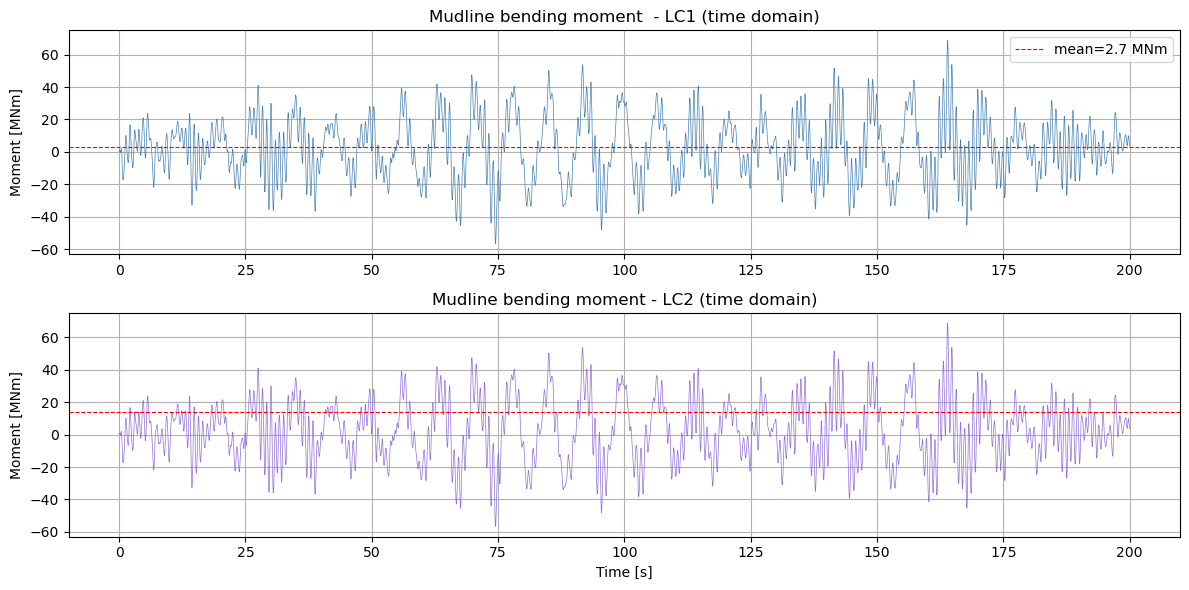

In [64]:
# ==== PLOT, MUDLINE MOMENT TIME SERIES ======
n_plot=int(200/dt)
_, axes= plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(np.arange(n_plot)*dt, M_mudline_LC1[:n_plot]/1e6, linewidth=0.5, color='steelblue')
axes[0].axhline(M_mudline_LC1.mean()/1e6, color='r', ls='--', lw=0.8, label=f'mean={M_mudline_LC1.mean()/1e6:.1f} MNm')
axes[0].set_ylabel('Moment [MNm]')
axes[0].set_title('Mudline bending moment  - LC1 (time domain)')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(np.arange(n_plot)*dt, M_mudline_LC1[:n_plot]/1e6, linewidth=0.5, color='mediumpurple')
axes[1].axhline(M_mudline_LC2.mean()/1e6, color='r', ls='--', lw=0.8, label=f'mean{M_mudline_LC2.mean()/1e6:.1f} MNm')
axes[1].set_ylabel('Moment [MNm]')
axes[1].set_title('Mudline bending moment - LC2 (time domain)')
axes[1].set_xlabel('Time [s]')
axes[1].grid(True)
plt.tight_layout()
plt.show()


In [53]:
# ==== TIME DOMAIN STATISTICS, FULL SUMMARY ====
from scipy.signal import welch

def tz_series(M, dt):
    """ Mean zero-crossing period from time series (zero-mean subtracted). """
    Md=M-M.mean()
    zc=np.where(np.diff(np.sign(Md)))[0]
    return 2*len(Md)*dt/len(zc)

std_td_LC1 = M_mudline_LC1.std()/1e6
std_td_LC2 = M_mudline_LC2.std()/1e6
mean_td_LC1 = M_mudline_LC1.mean()/1e6
mean_td_LC2 = M_mudline_LC2.mean()/1e6
max_td_LC1 = M_mudline_LC1.max()/1e6
max_td_LC2 = M_mudline_LC2.max()/1e6
min_td_LC1 = M_mudline_LC1.min()/1e6
min_td_LC2 = M_mudline_LC2.min()/1e6
Tz_td_LC1 = tz_series(M_mudline_LC1, dt)
Tz_td_LC2 = tz_series(M_mudline_LC2, dt)

std_fd_LC1=std_LC1/1e6
std_fd_LC2=std_LC2/1e6

print(f"{'':22}{'LC1':>12}{'LC2':>12}")
print(f"{'Freq-domain std [MNm]':22}{std_fd_LC1:>12.2f}{std_fd_LC2:>12.2f}")
print(f"{'Time-domain std [MNm]':22}{std_td_LC1:>12.2f}{std_td_LC2:>12.2f}")
print(f"{'Time/freq ratio':22}{std_td_LC1/std_fd_LC1:>12.2f}{std_td_LC2/std_fd_LC2:>12.2f}")
print(f"{'Time-domain mean [MNm]':22}{mean_td_LC1:>12.2f}{mean_td_LC2:>12.2f}")
print(f"{'Time-domain max [MNm]':22}{max_td_LC1:>12.2f}{max_td_LC2:>12.2f}")
print(f"{'Time-domain min [MNm]':22}{min_td_LC1:>12.2f}{min_td_LC2:>12.2f}")
print(f"{'Freq-domain Tz [s]':22}{Tz_LC1:>12.2f}{Tz_LC2:>12.2f}")
print(f"{'Time-domain Tz [s]':22}{Tz_td_LC1:>12.2f}{Tz_td_LC2:>12.2f}")
print(f"{'Peak factor (max/std)':22}{max_td_LC1/std_td_LC1:>12.2f}{max_td_LC2/std_td_LC2:>12.2f}")

                               LC1         LC2
Freq-domain std [MNm]        21.89       29.73
Time-domain std [MNm]        18.66       25.13
Time/freq ratio               0.85        0.85
Time-domain mean [MNm]        2.70       13.98
Time-domain max [MNm]        68.68      106.73
Time-domain min [MNm]       -59.77      -74.66
Freq-domain Tz [s]            1.48        1.53
Time-domain Tz [s]            1.60        1.60
Peak factor (max/std)         3.68        4.25


## Step 7: Comparison of Frequency-Domain and Time-Domain Analyses

The frequency-domain analysis linearises the wave drag force using the equivalent linearisation method (Borgman), discarding the structural velocity from the forcing. The time-domain analysis integrates the full non-linear Morison equation including relative kinematics. The two are compared below in terms of standard deviation, extreme values, mean zero-crossing period, and spectral content. 

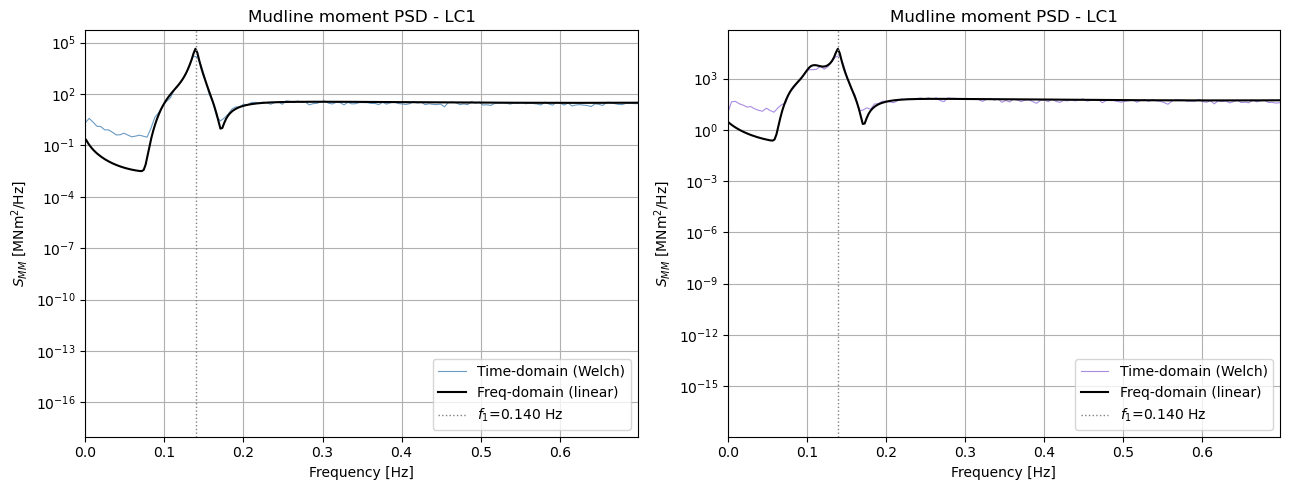

In [54]:
# ==== Step 7: Welch PSD vs FREQUENCY-DOMAIN S_MM ====
# Welch PSD of time-domain signal overlaid on analytical frequency-domain spectrum-
# Nperseg chosen to balance frequency resolution and variance of the estimate

from scipy.signal import welch

# Convert one-sided PSD from rad/s to Hz for overlay
S_MM_LC1_hz=S_MM_LC1*2*np.pi
S_MM_LC2_hz=S_MM_LC2*2*np.pi

nperseg=min(4096, N_t // 8)
f_welch_LC1, P_welch_LC1=welch(M_mudline_LC1, fs=1/dt, nperseg=nperseg)
f_welch_LC2, P_welch_LC2=welch(M_mudline_LC2, fs=1/dt, nperseg=nperseg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, fw, Pw, Sfd, lab, col in [
    (axes[0], f_welch_LC1, P_welch_LC1, S_MM_LC1_hz, 'LC1', 'steelblue'),
    (axes[1], f_welch_LC2, P_welch_LC2, S_MM_LC2_hz, 'LC1', 'mediumpurple')]:
    ax.semilogy(fw, Pw/1e12, color=col, lw=0.8, alpha=0.8, label='Time-domain (Welch)')
    ax.semilogy(f_axis, Sfd/1e12, 'k', lw=1.5, label='Freq-domain (linear)')
    ax.axvline(f1, color='gray', ls=':', lw=1, label=f'$f_1$={f1:.3f} Hz')
    ax.set_xlim(0, 5*f1)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('$S_{MM}$ [MNm$^2$/Hz]')
    ax.set_title(f'Mudline moment PSD - {lab}')
    ax.legend()
    ax.grid(True, which='both')
plt.tight_layout()
plt.show()

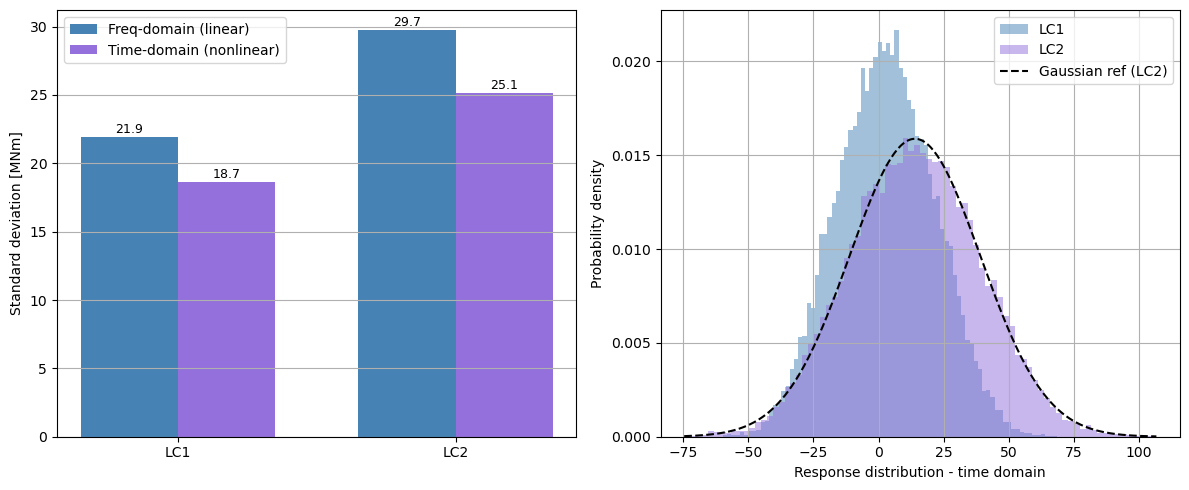

In [58]:
# ==== STEP 7: STATISTICAL COMPARISON PLOTS ====

fig, axes=plt.subplots(1,2, figsize=(12,5))

# --- Bar chart: std comparison ---
labels= ['LC1', 'LC2']
std_fd=[std_fd_LC1, std_fd_LC2]
std_td=[std_td_LC1, std_td_LC2]
x=np.arange(len(labels))
w=0.35
axes[0].bar(x-w/2, std_fd, w, label='Freq-domain (linear)', color='steelblue')
axes[0].bar(x+w/2, std_td, w, label='Time-domain (nonlinear)', color='mediumpurple')
for i, (f_, t_) in enumerate(zip(std_fd, std_td)):
    axes[0].text(i-w/2, f_ + 0.3, f'{f_:.1f}', ha='center', fontsize=9)
    axes[0].text(i+w/2, t_ + 0.3, f'{t_:.1f}', ha='center', fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Standard deviation [MNm]')
axes[0].legend(); axes[0].grid(True, axis='y')

# Histogram: time-domain repsonse vs Gaussian reference ---
# A Gaussian process would have a symmetric bell-shape with sigma=std_td.
# Deviation (skew, heavy tail) indicates nonlinear effects.
bins=80
for M, std_, lab, col in [
    (M_mudline_LC1/1e6, std_td_LC1, 'LC1', 'steelblue'),
    (M_mudline_LC2/1e6, std_td_LC2, 'LC2', 'mediumpurple')]:
    axes[1].hist(M, bins=bins, density=True, alpha=0.5, color=col, label=lab)
# overlay Gaussian reference for LC2 (most nonlinear)
from scipy.stats import norm
x_ref=np.linspace(M_mudline_LC2.min()/1e6, M_mudline_LC2.max()/1e6, 300)
axes[1].plot(x_ref, norm.pdf(x_ref, mean_td_LC2, std_td_LC2), 'k--', lw=1.5,
             label='Gaussian ref (LC2)')
axes[1].set_xlabel('Mudline moment [MNm]')
axes[1].set_ylabel('Probability density')
axes[1].set_xlabel('Response distribution - time domain')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.show()

### Conclusions

**Summary table**
| | Freq-domain | Time-domain | Ratio |
|---|---|---|---|
| LC1 std [MNm] | 21.89 | 18.66 | 0.85 |
| LC2 std [MNm] | 29.73 | 25.13 | 0.85 |
| LC1 mean [MNm] | - | 2.70 | - |
| LC2 mean [MNm] | - | 13.98 | - |
| LC1 $T_z$ [s] | 1.48 | 1.60 | - |
| LC2 $T_z$ [s] | 1.53 | 1.60 | - |
| LC1 max [MNm] | - | 68.68 | - |
| LC2 max [MNm] | - | 106.73 | - |

The frequency domain consistently overestimates the standard deviation by approximately 15% relative to the time domain for both load cases. This is attributed to the linearisation of the drag term in the frequency domain, where one factor of $|u|$ is replaced by $u_{rms}$. For the sea states considered, with maximum orbital velocities of approximately 1.96 m/s (LC1) and 3.06 m/s (LC2), this linearisation overestimates the effective drag force compared to the true |u|u dependence. The consistent ratio of 0.85 across both load cases confirms that the discrepancy is systematic rather than a numerical artefact. 

A secondary contribution comes from the relative kinematics formulation in the time domain. The nonlinear Morison equation exxounts for the velocity and acceleration of the structure itself, so the effective forcing depends on the fluid-structure relative velocity (u-$\dot{x}$) rather than the absolute fluid velocity u alone. The structural motion opposing the fluid velocity reduces the net hydrodynamic force, introducing an effective aerodynamic-type damping that is absent in the linearised frequency domain formualtion where structural motion is decoupled form the forcing. This further reduces the time domain response relative to the frequency domain prediction. 

Both effects act in the same direction and together account for the consistent 15% overestimate. The frequency domain result nonetheless remains a useful and conservative upper bound, and the close agreement in spectral shape, confirmed by the Welch PSD overlay, dempinstrates that the linearised approach correctly captures the dominant frequency content and resonance behaviour even if it overestimates the total variance.

The bar chart confirms that the frequency domain consistently overestimates the standard deviation by approximately 15% relative to the time domain for both load cases, as discussed above. 

The response histograms show that both load cases are approximately Gaussian. LC1 shows a narrower, higher peak reflecting its power variance, while LC2 has a broader distribution. The nea-Gaussian shape confirms tha tnonlinear drag effects, while present, do not fundamentally alter the response statistics for these sea states. 

**Frequency content (Welch vs analytical PSD)**

The Welch PSD of the time-domain signal agrees well with the analytical frequency-domain PSD in the low-frequency range, confirming that the FRF-based approach captures the dominant spectral content correctly. At higher frequencies ($f > 2f_1$), the time-domain signal shows excess energy, the signature of nonlinear drag generating higher harmonics at $2\omega_p$, $3\omega_p$, which the linearised model cannot reproduce. This effect is more pronounced in LC2, where the larger orbital velocities produce a stronger nonlinear contribution. 
Despite LC1 being tuned for resonance, LC2 produces a higher standard deviation in both domains, driven by its larger significant wave height and stronger wind loading, the resonance advantage of LC1 is outweighted by the greater energy input of LC2. 

## Diffraction Assessment

The Morison equation is valid only when the structure is slender relative to the wavelength. The criterion is:

$$\frac{D}{\lambda} < 0.2$$

where the wavelength $\lambda=2\pi/k$ and $k$ satisfies the dispersion relation:

$$\omega^2=gk\tanh(kh)$$

The peak frequencies are checked for both load cases. If $D/\lambda < 0.2 $ , Morison is valid and diffraction effects can be neglected. 

In [56]:
# ==== DIFFRACTION ASSESSMENT =====
omega_p_LC1=2*np.pi/Tp_LC1
omega_p_LC2=2*np.pi/Tp_LC2
# Dispersion relation at peak frequencies
for name, fp, in [('LC1', fp_LC1),
                          ('LC2', fp_LC2)]:
    k_p=wave_numbers(np.array([fp]), Hw)[0]
    lam=2*np.pi/k_p
    ratio=D_o/lam
    valid="valid" if ratio < 0.2 else "INVALID - diffraction effects needed"
    print(f"{name}: lambda={lam:.1f} m, D/lambda={ratio:.3f} -> Morison {valid}")
    

LC1: lambda=79.5 m, D/lambda=0.066 -> Morison valid
LC2: lambda=129.8 m, D/lambda=0.040 -> Morison valid


For both load cases $D/\lambda$ is well below 0.2, confirming that the structure is hydrodynamically slender and the Morison equation is applicable without diffraction correction.

**Effect of including diffraction:**
At the peak frequencies, the MacCamy-Fuchs correction factor modifies the inertia coefficient from $C_m=2.0$ toward a frequency-dependent value that decreases as $D/\lambda$ approaches 0.2 Given the small ratios found here ($D/\lambda\approx 0.07$ for LC1 and $\approx 0.04$ for LC2), the correction would reduce the effective inertia loading by only a few percent, well within engineering tolerance. The effect is larger for LC1 than LC2 because the shorter wave period in LC1 corresponds to a shorter wavelength and therefore a slightly less slender pile relative to the wave. In neither case including diffraction materially change the mudline moment statistics or the conclusions of the analysis. 

## References

Hasselmann, K. et al. (1973). *Measurements of wind-wave growth and swell decay during the Joint North Sea Wave Project (JONSWAP)*. Deutsches Hydrographisches Institut, Hamburg. 

IEC 61400-1 (2019). *Wind Energy Generation Systems - Part 1: Design Requirements*. International Electrotechnical Commission, Geneva. 

DNV-OS-J101 (2014). *Design of Offshore Wind Turbine Structures*. Det Norske Veritas, Oslo.

Kaimal, J.C., Wyngaard, J.C., Izumi, Y, and Coté, O.R. (1972). Spectral characteristics of surface-layer turbulence. *Quarterly Journal of the Royal Meteorological Society*, 98(417), pp. 563-589. 

Kolmogorov, A.N. (1941). The local structure of turbulence in incompressible viscous fluid for very large Reynolds numbers. *Doklady Akademii Nauk SSSR*, 30, pp. 299-303.

Pierson, W.J. and Moskowitz, L. (1964). A proposed spectral form for fully developed wind seas based on the similarity theory of S.A. Kitaigorodskii. *Journal of Geophysical Research*, 69(24), pp. 5181-5190. 

Sumer, B.M. and Fredsøe, J. (2002). *The Mechanics of Scour in the Marine Environment*, World Scientific, Singapore. 

Sørensen, S.P.H and Ibsen, L.B. (2013). Assessment of foundation design for offshore monopiles unprotected against scour. *Ocean Engineering*, 63, pp. 17-25.





**Use of AI Tools**
Claude (Anthropic) was used as a coding assistant throughout this project. Its primary roles were:
* **Code development and debugging:** Providing support with organising the notebook into logical sections, suggesting consistent naming conventions, and ensuring dependencies between cells were consistent. 

* **Report writing:** Supporting the structure and flow of written sections, helping with jupyter formating and keeping track of hardcoded numerical values ensuring that they were updated with the script.

* **Debugging:** helping identify unit inconsistencies in the frequency axis conversion from rad/s to Hz across the JONSWAP spectrum,wave force and mudline moment spectrum calculations.

* **Sanity checking:** helping identify potential issues in results, such as the frequency vs time domain standard deviation comparison, and confirming physical reasonableness of outputs.